# DSAA2011 Project Notebook

This notebook completes all mandatory tasks in the project PDF and includes an open-ended exploration section.

Dataset used: `data.csv` (Student Dropout dataset).

In [11]:
import os
import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, label_binarize,
)
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.cluster import (
    KMeans, MiniBatchKMeans, AgglomerativeClustering,
    Birch, SpectralClustering, DBSCAN,
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, classification_report
)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
)
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 6)
RANDOM_STATE = 42

## Task 1: Data Preprocessing

**Objective:** Prepare the Student Dropout dataset for downstream ML tasks (t-SNE, clustering, classification).

**Applied methods:**
1. **Missing value audit** - full column-wise check; median imputation for numeric, mode for categorical (as a safeguard, though the dataset has zero nulls).
2. **Semantic feature typing** - all 36 raw features are stored as numbers, but many are integer-encoded categories (e.g. `Course`, `Nacionality`). We manually classify them into *binary*, *nominal categorical*, and *true numeric* groups based on domain meaning rather than dtype.
3. **Near-zero-variance filtering** - features where > 95 % of values are a single category are dropped to reduce sparse noise.
4. **Highly-correlated feature pruning** - among feature pairs with |r| > 0.90, one is dropped to reduce redundancy.
5. **Feature engineering** - 3 new features capturing academic trajectory: semester approval rates and grade trend.
6. **StandardScaler** - applied to numeric features after median imputation so all continuous/count variables contribute on comparable scale.
7. **OneHotEncoder** - nominal categoricals encoded without using the target label, keeping t-SNE and clustering free from label leakage.
8. **Binary passthrough** - 0/1 features passed through unchanged.

### Step 1 - Load Data & Quality Check


In [12]:
# ── 1a. Load ────────────────────────────────────────────────────────
try:
    df = pd.read_csv('data/data.csv', sep=';')
except FileNotFoundError:
    df = pd.read_csv('data.csv', sep=';')
df.columns = df.columns.str.strip()

target_col = 'Target'
X_raw = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print(f'Rows: {df.shape[0]},  Columns: {df.shape[1]}')
print(f'\nTarget distribution:')
for cls, cnt in y.value_counts().items():
    print(f'  {cls:12s}: {cnt:5d}  ({cnt / len(y) * 100:.1f} %)')

# ── 1b. Missing values ─────────────────────────────────────────────
total_missing = df.isna().sum().sum()
print(f'\nTotal missing values: {total_missing}')
if total_missing > 0:
    print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
else:
    print('→ No missing values detected. Imputers are kept in the pipeline as a safeguard.')

# ── 1c. Duplicate rows ─────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'\nDuplicate rows: {n_dup}')

# ── 1d. Class imbalance ────────────────────────────────────────────
vc = y.value_counts()
print(f'Imbalance ratio (majority / minority): {vc.max() / vc.min():.2f}')

Rows: 4424,  Columns: 37

Target distribution:
  Graduate    :  2209  (49.9 %)
  Dropout     :  1421  (32.1 %)
  Enrolled    :   794  (17.9 %)

Total missing values: 0
→ No missing values detected. Imputers are kept in the pipeline as a safeguard.

Duplicate rows: 0
Imbalance ratio (majority / minority): 2.78


### Step 2 · Semantic Feature Classification & Quality Visualizations

All 36 raw features are stored as numbers, but many are **integer-encoded categories** whose numeric magnitude is meaningless (e.g. `Course` values 33, 171, 8014 … 9991 are programme IDs). We manually classify every feature by its real-world semantics.

Binary features  (8): ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
Nominal features (9): ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Numeric features (19): ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 

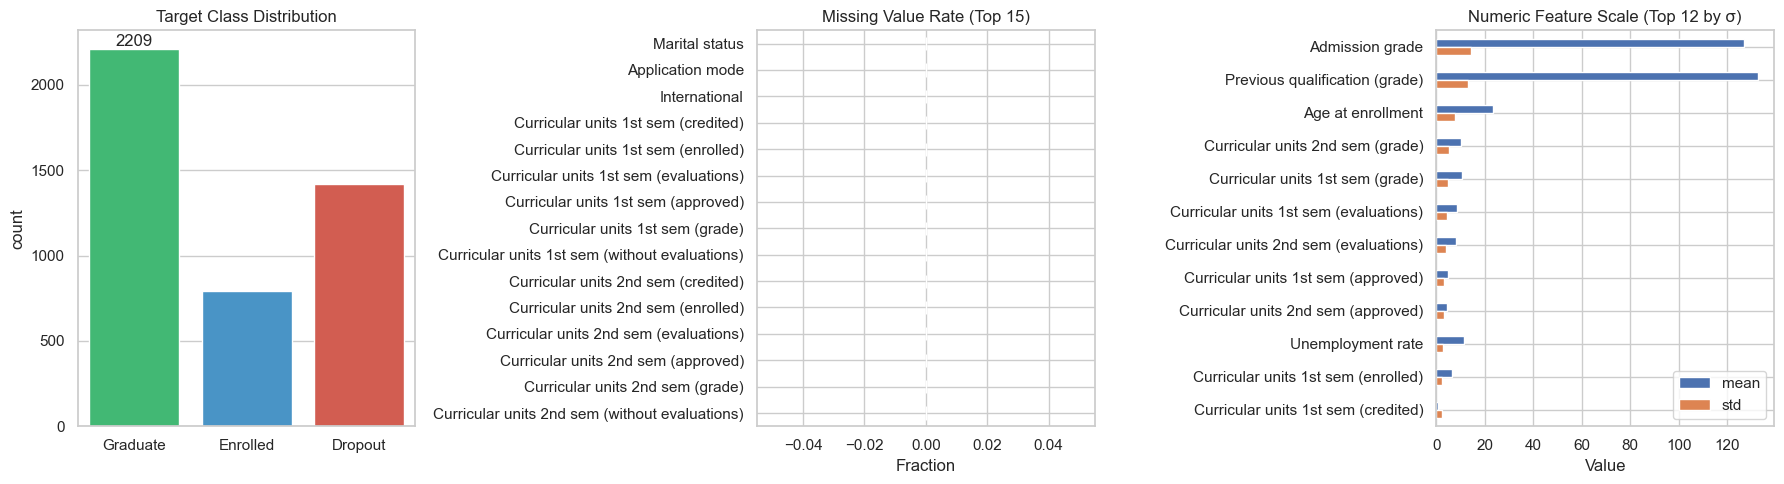

In [13]:
# ── 2a. Manual semantic classification ──────────────────────────────
BINARY_COLS = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International',
]

NOMINAL_COLS = [
    'Marital status', 'Application mode', 'Course',
    'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
]

NUMERIC_COLS = [c for c in X_raw.columns if c not in BINARY_COLS + NOMINAL_COLS]

print(f'Binary features  ({len(BINARY_COLS)}): {BINARY_COLS}')
print(f'Nominal features ({len(NOMINAL_COLS)}): {NOMINAL_COLS}')
print(f'Numeric features ({len(NUMERIC_COLS)}): {NUMERIC_COLS}')
print(f'Total: {len(BINARY_COLS) + len(NOMINAL_COLS) + len(NUMERIC_COLS)}  (should be {X_raw.shape[1]})')

# ── 2b. Target distribution plot ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#3498db'}
sns.countplot(x=y, order=['Graduate', 'Enrolled', 'Dropout'], palette=palette, ax=axes[0])
axes[0].set_title('Target Class Distribution')
axes[0].bar_label(axes[0].containers[0])
axes[0].set_xlabel('')

# ── 2c. Missing value heatmap (confirming zero missingness) ────────
missing_pct = X_raw.isna().mean().sort_values(ascending=False).head(15)
missing_pct.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Missing Value Rate (Top 15)')
axes[1].set_xlabel('Fraction')
axes[1].invert_yaxis()

# ── 2d. Feature scale disparity ────────────────────────────────────
scale_df = X_raw[NUMERIC_COLS].agg(['mean', 'std']).T.sort_values('std', ascending=False).head(12)
scale_df.plot.barh(ax=axes[2])
axes[2].set_title('Numeric Feature Scale (Top 12 by σ)')
axes[2].set_xlabel('Value')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Step 3 - Feature Filtering (near-zero variance, correlation, and controlled complexity)

- **Near-zero variance:** features where one value accounts for more than 95% of rows carry very little information and can create unstable sparse dummy columns. We remove `Educational special needs` (98.8% = 0), `International` (97.5% = 0), and `Nacionality` (97.5% = 1).
- **High-correlation audit:** we inspect numeric feature pairs with absolute correlation above 0.90. Clearly redundant administrative semester-count pairs are pruned:
  - `Curricular units 1st sem (credited)` vs `2nd sem (credited)` (r = 0.945): drop the 1st-semester credited column.
  - `Curricular units 1st sem (enrolled)` vs `2nd sem (enrolled)` (r = 0.943): drop the 1st-semester enrolled column.
- **Domain-aware exception:** `Curricular units 1st sem (approved)` and `2nd sem (approved)` are also highly correlated, but both are kept because they represent academic progression at different time points and are central to dropout risk. Dropping one would remove useful temporal signal.
- **Controlled categorical complexity:** `Father's occupation` is removed as a high-cardinality parental occupation field to reduce sparse one-hot expansion while retaining related family-background information through other parent-background variables.


In [14]:
# ── 3a. Near-zero-variance detection ───────────────────────────────
NZV_THRESHOLD = 0.95
nzv_cols = []
for col in X_raw.columns:
    top_pct = X_raw[col].value_counts(normalize=True).iloc[0]
    if top_pct > NZV_THRESHOLD:
        nzv_cols.append((col, top_pct))
        print(f'  NZV → {col}: dominant value occupies {top_pct:.1%}')

DROP_NZV = [c for c, _ in nzv_cols]

# ── 3b. High-correlation detection ─────────────────────────────────
CORR_THRESHOLD = 0.90
corr_matrix = X_raw[NUMERIC_COLS].corr().abs()
high_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if r > CORR_THRESHOLD:
            high_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
            print(f'  CORR → {corr_matrix.columns[i]}  ↔  {corr_matrix.columns[j]}  (r={r:.3f})')

DROP_CORR = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    "Father's occupation",
]

# ── 3c. Apply drops ───────────────────────────────────────────────
DROP_ALL = list(set(DROP_NZV + DROP_CORR))
X = X_raw.drop(columns=DROP_ALL).copy()
print(f'\nDropped {len(DROP_ALL)} features: {DROP_ALL}')
print(f'Remaining features: {X.shape[1]}')

# Update column lists after dropping
BINARY_COLS = [c for c in BINARY_COLS if c not in DROP_ALL]
NOMINAL_COLS = [c for c in NOMINAL_COLS if c not in DROP_ALL]
NUMERIC_COLS = [c for c in X.columns if c not in BINARY_COLS + NOMINAL_COLS]

print(f'\nAfter filtering — Binary: {len(BINARY_COLS)}, Nominal: {len(NOMINAL_COLS)}, Numeric: {len(NUMERIC_COLS)}')

  NZV → Nacionality: dominant value occupies 97.5%
  NZV → Educational special needs: dominant value occupies 98.8%
  NZV → International: dominant value occupies 97.5%
  CORR → Curricular units 1st sem (credited)  ↔  Curricular units 2nd sem (credited)  (r=0.945)
  CORR → Curricular units 1st sem (enrolled)  ↔  Curricular units 2nd sem (enrolled)  (r=0.943)
  CORR → Curricular units 1st sem (approved)  ↔  Curricular units 2nd sem (approved)  (r=0.904)

Dropped 6 features: ["Father's occupation", 'Curricular units 1st sem (enrolled)', 'International', 'Educational special needs', 'Nacionality', 'Curricular units 1st sem (credited)']
Remaining features: 30

After filtering — Binary: 6, Nominal: 7, Numeric: 17


### Step 3.5 - Feature Engineering

We construct three new features that capture **academic trajectory**, one of the strongest predictor groups for student outcomes.

| New Feature | Formula | Rationale |
|-------------|---------|-----------|
| `approval_rate_1st` | approved_1st / (evaluations_1st + 1) | First-semester approval rate; directly measures early academic success while accounting for evaluated units. |
| `approval_rate_2nd` | approved_2nd / (evaluations_2nd + 1) | Second-semester approval rate; captures later academic progress. |
| `grade_trend` | grade_2nd - grade_1st | Positive = improving, negative = declining; captures trajectory direction. |

The `+1` in the denominator prevents division by zero for students with zero evaluations.


In [15]:
# ── 3.5 Feature engineering ─────────────────────────────────────────
X['approval_rate_1st'] = (
    X['Curricular units 1st sem (approved)']
    / (X['Curricular units 1st sem (evaluations)'] + 1)
)
X['approval_rate_2nd'] = (
    X['Curricular units 2nd sem (approved)']
    / (X['Curricular units 2nd sem (evaluations)'] + 1)
)
X['grade_trend'] = (
    X['Curricular units 2nd sem (grade)']
    - X['Curricular units 1st sem (grade)']
)

NUMERIC_COLS = NUMERIC_COLS + ['approval_rate_1st', 'approval_rate_2nd', 'grade_trend']

print(f'Engineered 3 new features → total columns: {X.shape[1]}')
print(f'Updated NUMERIC_COLS count: {len(NUMERIC_COLS)}')

Engineered 3 new features → total columns: 33
Updated NUMERIC_COLS count: 20


### Step 4 - Build Preprocessing Pipeline & Transform

Pipeline used for the main analysis:
- **Numeric path:** `StandardScaler` standardizes numeric/count features after median imputation. This directly matches the project requirement to standardize features and performed slightly better than the Yeo-Johnson alternative in cross-validation.
- **Categorical path:** `OneHotEncoder(handle_unknown='ignore', drop='first')` encodes integer-coded nominal variables without imposing false numeric order and without using `Target`. This is safer for t-SNE and clustering because the representation remains unsupervised.
- **Binary path:** `passthrough` - unchanged because 0/1 values are already meaningful.

Target encoding is intentionally not used in the main preprocessing pipeline because it depends on labels and can leak target information into unsupervised tasks.


In [16]:
# ---- 4a. Pipeline definition ----
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
])

binary_transformer = 'passthrough'

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_COLS),
        ('cat', categorical_transformer, NOMINAL_COLS),
        ('bin', binary_transformer, BINARY_COLS),
    ],
    remainder='drop',
)

# ---- 4b. Fit & Transform for visualization/clustering ----
# This fit uses X only; no target labels are passed into preprocessing.
X_processed = preprocessor.fit_transform(X)
X_dense = X_processed if isinstance(X_processed, np.ndarray) else X_processed.toarray()

feature_names = preprocessor.get_feature_names_out()

print(f'Original features:         {X_raw.shape[1]}')
print(f'After filtering:           {X.shape[1]}  (dropped {X_raw.shape[1] - X.shape[1] + 3} raw + added 3 engineered)')
print(f'After transformation:      {X_dense.shape[1]}')
print(f'   Numeric (StandardScaler):   {len(NUMERIC_COLS)}')
print(f'   Nominal (OneHotEncoder):    {len(NOMINAL_COLS)} raw -> {X_dense.shape[1] - len(NUMERIC_COLS) - len(BINARY_COLS)} encoded columns')
print(f'   Binary  (passthrough):      {len(BINARY_COLS)}')

# ---- 4c. Sanity check ----
assert not np.isnan(X_dense).any(), 'NaN detected after transformation!'
assert not np.isinf(X_dense).any(), 'Inf detected after transformation!'
print(f'\nSanity check passed - final matrix shape: {X_dense.shape}')


Original features:         36
After filtering:           33  (dropped 6 raw + added 3 engineered)
After transformation:      172
   Numeric (StandardScaler):   20
   Nominal (OneHotEncoder):    7 raw -> 146 encoded columns
   Binary  (passthrough):      6

Sanity check passed - final matrix shape: (4424, 172)


### Step 5 - Diagnostic Visualizations for Preprocessing Quality

To make the preprocessing effect visible, we add three report-oriented diagnostics:

1. Class distribution and imbalance ratio.
2. Numeric-feature correlation heatmap after feature filtering and engineering.
3. Raw-vs-standardized numeric scale comparison, showing why scaling is necessary before distance-based methods and linear models.


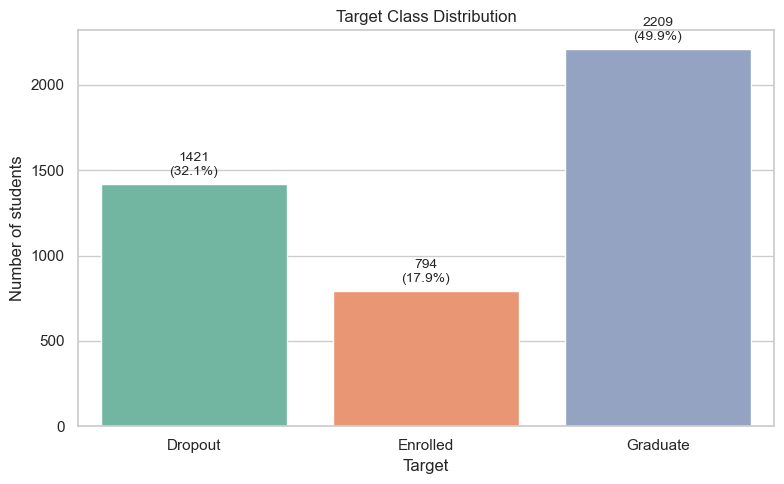

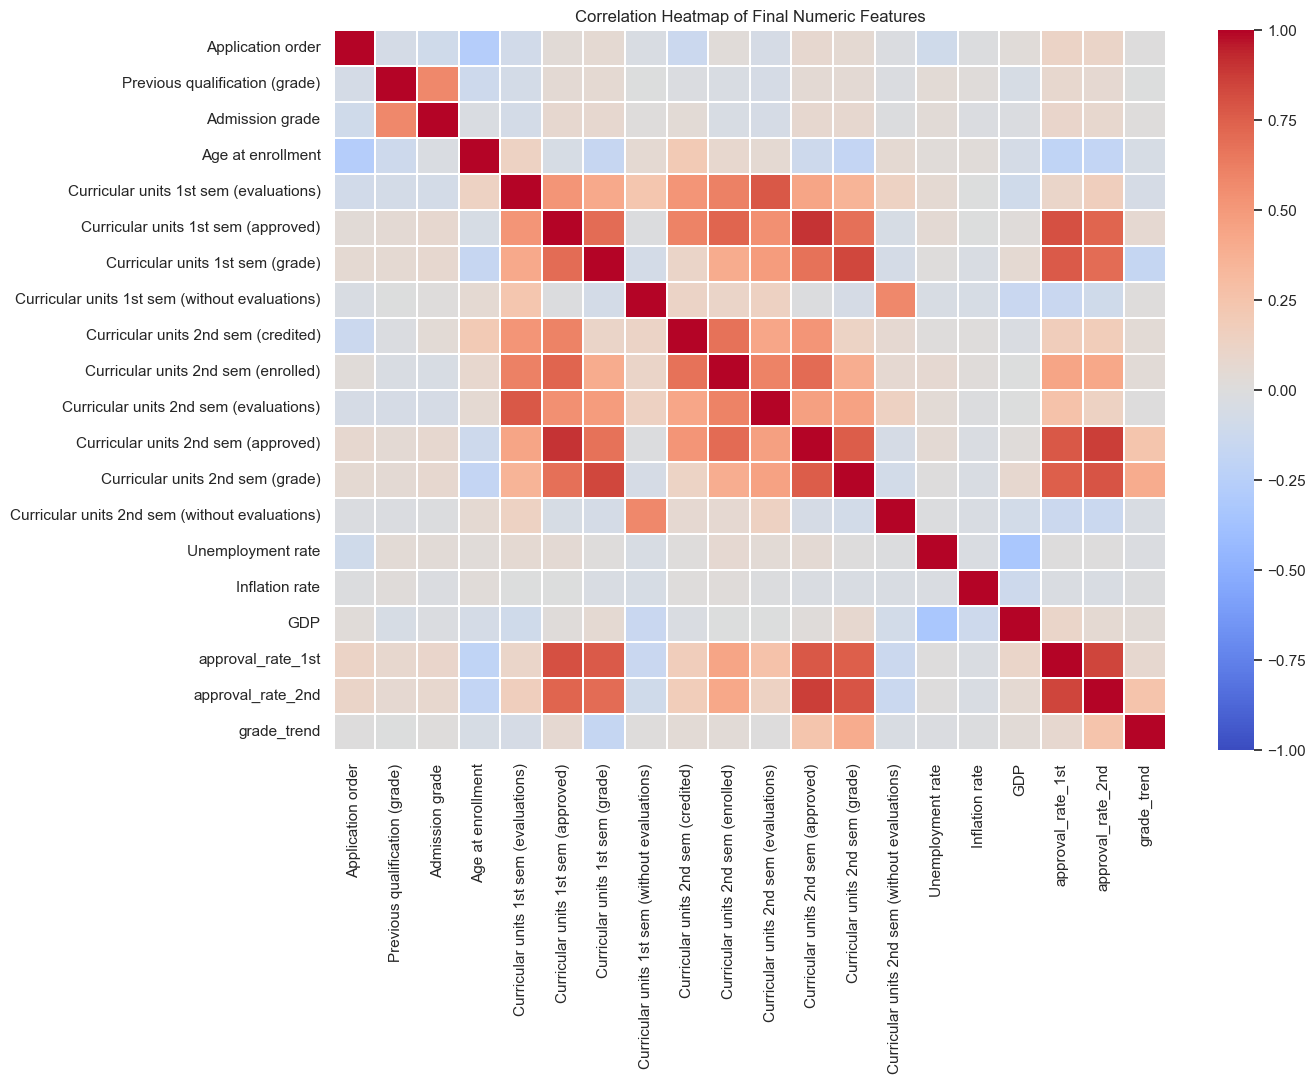

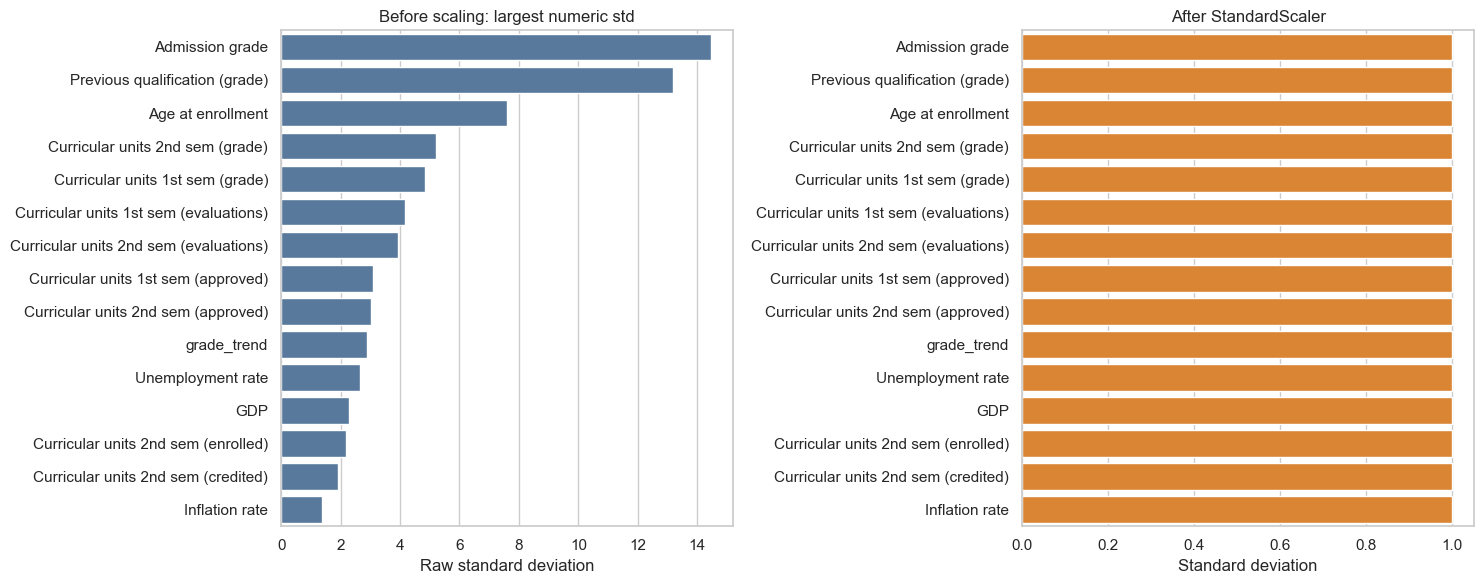

,Count,Percentage
Target,,
Dropout,1421,32.12
Enrolled,794,17.95
Graduate,2209,49.93


,Raw std,After StandardScaler std
Admission grade,14.482,1.0
Previous qualification (grade),13.188,1.0
Age at enrollment,7.588,1.0
Curricular units 2nd sem (grade),5.211,1.0
Curricular units 1st sem (grade),4.844,1.0
Curricular units 1st sem (evaluations),4.179,1.0
Curricular units 2nd sem (evaluations),3.948,1.0
Curricular units 1st sem (approved),3.094,1.0
Curricular units 2nd sem (approved),3.015,1.0
grade_trend,2.890,1.0


,Feature 1,Feature 2,abs_corr
0,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904


Imbalance ratio (majority/minority): 2.78
Number of final numeric feature pairs with |corr| > 0.90: 1
Interpretation - class distribution: Enrolled is the minority class, so macro metrics are needed later.
Interpretation - correlation heatmap: remaining high correlation is domain-aware and tied to temporal academic progression.
Interpretation - scale effect: StandardScaler prevents large-range numeric features from dominating distance-based methods.


In [17]:
# ---- Task 1 Diagnostic Visualizations ----
from pathlib import Path

Path('docs/figures').mkdir(parents=True, exist_ok=True)

# 1) Class imbalance visualization
class_counts = y.value_counts().reindex(['Dropout', 'Enrolled', 'Graduate'])
class_percent = class_counts / len(y) * 100
class_summary = pd.DataFrame({'Count': class_counts, 'Percentage': class_percent.round(2)})

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=class_summary.index, y=class_summary['Count'], palette='Set2')
for i, (cnt, pct) in enumerate(zip(class_summary['Count'], class_summary['Percentage'])):
    ax.text(i, cnt + 35, f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
plt.title('Target Class Distribution')
plt.xlabel('Target')
plt.ylabel('Number of students')
plt.tight_layout()
plt.savefig('docs/figures/task1_class_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

# 2) Correlation heatmap for final numeric features
numeric_corr = X[NUMERIC_COLS].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(numeric_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=False, linewidths=0.2)
plt.title('Correlation Heatmap of Final Numeric Features')
plt.tight_layout()
plt.savefig('docs/figures/task1_numeric_correlation_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

# 3) Preprocessing scale effect: raw numeric std vs standardized numeric std
raw_std = X[NUMERIC_COLS].std().sort_values(ascending=False)
scaled_numeric = pd.DataFrame(X_dense[:, :len(NUMERIC_COLS)], columns=NUMERIC_COLS)
scaled_std = scaled_numeric.std().reindex(raw_std.index)
scale_compare = pd.DataFrame({
    'Raw std': raw_std,
    'After StandardScaler std': scaled_std,
}).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=scale_compare['Raw std'], y=scale_compare.index, ax=axes[0], color='#4C78A8')
axes[0].set_title('Before scaling: largest numeric std')
axes[0].set_xlabel('Raw standard deviation')
axes[0].set_ylabel('')
sns.barplot(x=scale_compare['After StandardScaler std'], y=scale_compare.index, ax=axes[1], color='#F58518')
axes[1].set_title('After StandardScaler')
axes[1].set_xlabel('Standard deviation')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('docs/figures/task1_preprocessing_scale_effect.png', dpi=180, bbox_inches='tight')
plt.show()

# High-correlation pairs retained after final numeric preprocessing audit
corr_abs = numeric_corr.abs()
upper_mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
high_corr_pairs = (
    corr_abs.where(upper_mask)
    .stack()
    .sort_values(ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.90]

display(class_summary)
display(scale_compare.round(3))
display(high_corr_pairs.rename('abs_corr').reset_index().rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2'}).round(3))
print(f'Imbalance ratio (majority/minority): {class_counts.max() / class_counts.min():.2f}')
print(f'Number of final numeric feature pairs with |corr| > 0.90: {len(high_corr_pairs)}')
print('Interpretation - class distribution: Enrolled is the minority class, so macro metrics are needed later.')
print('Interpretation - correlation heatmap: remaining high correlation is domain-aware and tied to temporal academic progression.')
print('Interpretation - scale effect: StandardScaler prevents large-range numeric features from dominating distance-based methods.')


### Step 5 Interpretation

The diagnostic figures support the preprocessing decisions:

- **Class distribution:** `Enrolled` is clearly the minority class, while `Graduate` is the majority. This motivates macro-averaged metrics and balanced model variants in later supervised learning.
- **Numeric correlation heatmap:** most redundant semester-count relationships have been reduced, but one high-correlation academic pair remains intentionally because 1st- and 2nd-semester approval counts represent progression over time rather than duplicate information.
- **Scale comparison:** raw numeric features have very different standard deviations, so unscaled distances would be dominated by large-range variables. After `StandardScaler`, numeric features contribute on a comparable scale, which supports t-SNE, clustering, SVM, and linear models.


### Preprocessing Summary & Key Insights

| Aspect | Finding |
|--------|---------|
| **Missing values** | 0 across all 37 columns - no imputation needed, but imputers are kept for robustness. |
| **Duplicates** | 0 duplicate rows. |
| **Class imbalance** | Graduate 49.9%, Dropout 32.1%, Enrolled 17.9% (majority/minority ratio about 2.8:1). Macro-averaged metrics are preferred. |
| **Feature typing** | 36 raw features are manually split by semantics into binary, nominal-categorical, and numeric/count groups. |
| **Dropped features** | 3 near-zero-variance fields (`Educational special needs`, `International`, `Nacionality`), 2 redundant semester-count fields (`1st sem credited`, `1st sem enrolled`), and 1 high-cardinality parental occupation field (`Father's occupation`). |
| **Domain-aware retention** | `1st sem approved` and `2nd sem approved` are highly correlated but retained because they represent different time points in academic progression. |
| **Feature engineering** | 3 new features: `approval_rate_1st`, `approval_rate_2nd`, and `grade_trend`, all focused on academic trajectory. |
| **StandardScaler** | Numeric features are standardized after median imputation, matching the project requirement and stabilizing distance-based and linear models. |
| **OneHotEncoder** | Nominal categories are encoded without using target labels, avoiding leakage in t-SNE and clustering. |
| **Diagnostic figures** | Class distribution, numeric correlation heatmap, and raw-vs-standardized scale comparison are generated for report evidence. |
| **Final dimensions** | 172 transformed columns: 20 numeric, 146 one-hot categorical, and 6 binary passthrough columns. |


## Task 2: Data Visualization (t-SNE)

This task visualizes the preprocessed high-dimensional student records in a 2D space using t-SNE.

High-score design choices:
- Use the leakage-free preprocessing matrix `X_dense`; no target labels are used to construct the embedding.
- Apply PCA before t-SNE to reduce noise and improve runtime stability.
- Color points by the true `Target` labels only after the embedding is computed.
- Add centroid and within-class spread summaries to support, but not replace, visual interpretation.

Important note: t-SNE is mainly a qualitative neighborhood visualization. Global distances and cluster sizes should not be over-interpreted.


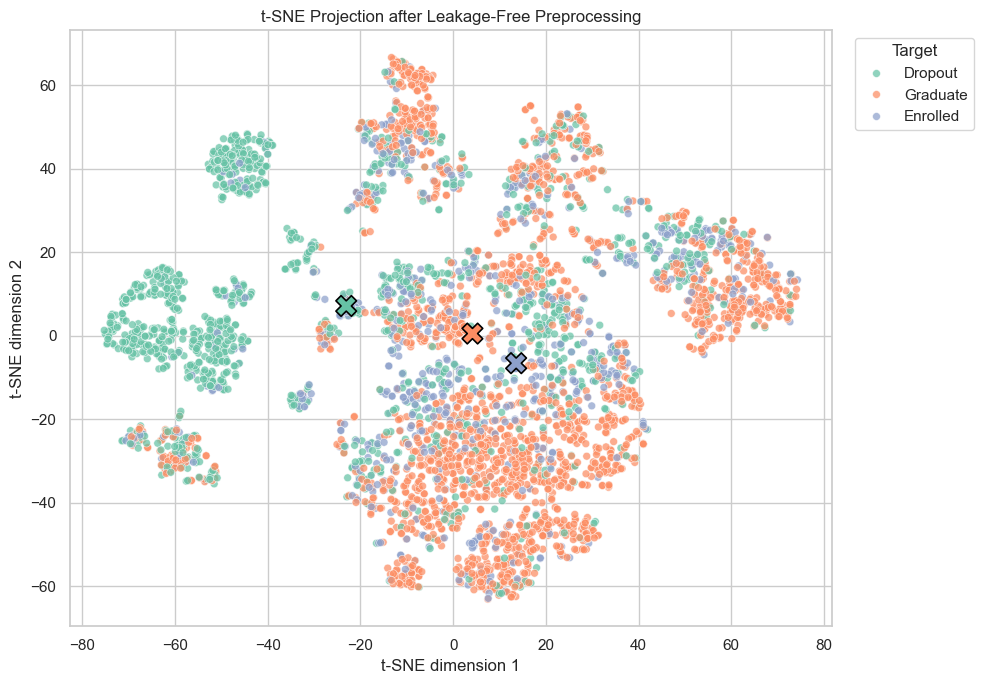

Preprocessed feature matrix: (4424, 172)
PCA dimensions before t-SNE: 50
PCA cumulative explained variance: 0.9744
t-SNE KL divergence: 1.4722
Nearest class-centroid pair on t-SNE plane: Enrolled - Graduate (11.798)


,TSNE-1,TSNE-2
Target,,
Dropout,-23.059999,7.132
Enrolled,4.165000,0.522
Graduate,13.588000,-6.579


,mean,median,std
Target,,,
Dropout,41.233002,41.019001,15.891
Enrolled,36.187000,35.919998,16.858
Graduate,39.792000,40.634998,17.033


Target,Dropout,Enrolled,Graduate
Target,,,
Dropout,0.000,28.016,39.129
Enrolled,28.016,0.000,11.798
Graduate,39.129,11.798,0.000


Interpretation: The t-SNE projection shows partial class structure but also substantial overlap. The closest centroid pair is Enrolled-Graduate, suggesting these classes are more visually mixed in the learned representation. This supports using supervised models and macro-averaged evaluation rather than expecting perfect natural clusters.


In [19]:
# ---- t-SNE on leakage-free preprocessed features ----
from pathlib import Path

pca_dims = min(50, X_dense.shape[1])
pca_for_tsne = PCA(n_components=pca_dims, random_state=RANDOM_STATE)
X_for_tsne = pca_for_tsne.fit_transform(X_dense)
pca_variance = pca_for_tsne.explained_variance_ratio_.sum()

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    init='pca',
    learning_rate='auto',
    perplexity=30,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_for_tsne)

tsne_df = pd.DataFrame({
    'TSNE-1': X_tsne[:, 0],
    'TSNE-2': X_tsne[:, 1],
    'Target': y.values,
})

centroids = tsne_df.groupby('Target')[['TSNE-1', 'TSNE-2']].mean()
spread_df = tsne_df.join(centroids, on='Target', rsuffix='_centroid')
spread_df['distance_to_class_centroid'] = np.sqrt(
    (spread_df['TSNE-1'] - spread_df['TSNE-1_centroid']) ** 2
    + (spread_df['TSNE-2'] - spread_df['TSNE-2_centroid']) ** 2
)
spread_summary = (
    spread_df.groupby('Target')['distance_to_class_centroid']
    .agg(['mean', 'median', 'std'])
    .sort_index()
)

centroid_dist = pd.DataFrame(index=centroids.index, columns=centroids.index, dtype=float)
for c1 in centroids.index:
    for c2 in centroids.index:
        centroid_dist.loc[c1, c2] = np.linalg.norm(centroids.loc[c1] - centroids.loc[c2])

upper_pairs = []
for i, c1 in enumerate(centroids.index):
    for c2 in centroids.index[i + 1:]:
        upper_pairs.append((centroid_dist.loc[c1, c2], c1, c2))
nearest_dist, nearest_c1, nearest_c2 = min(upper_pairs)

Path('docs/figures').mkdir(parents=True, exist_ok=True)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tsne_df, x='TSNE-1', y='TSNE-2', hue='Target',
    alpha=0.72, s=32, palette='Set2'
)
sns.scatterplot(
    data=centroids.reset_index(), x='TSNE-1', y='TSNE-2', hue='Target',
    marker='X', s=220, edgecolor='black', linewidth=1.2,
    palette='Set2', legend=False
)
plt.title('t-SNE Projection after Leakage-Free Preprocessing')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('docs/figures/tsne_projection.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Preprocessed feature matrix: {X_dense.shape}')
print(f'PCA dimensions before t-SNE: {pca_dims}')
print(f'PCA cumulative explained variance: {pca_variance:.4f}')
print(f't-SNE KL divergence: {tsne.kl_divergence_:.4f}')
print(f'Nearest class-centroid pair on t-SNE plane: {nearest_c1} - {nearest_c2} ({nearest_dist:.3f})')

display(centroids.round(3))
display(spread_summary.round(3))
display(centroid_dist.round(3))

print(
    'Interpretation: The t-SNE projection shows partial class structure but also substantial overlap. '
    'The closest centroid pair is Enrolled-Graduate, suggesting these classes are more visually mixed in the learned representation. '
    'This supports using supervised models and macro-averaged evaluation rather than expecting perfect natural clusters.'
)


### t-SNE Perplexity Sensitivity Analysis

A single t-SNE plot can be sensitive to the perplexity parameter. To avoid over-interpreting one view, we compare perplexity values `10`, `30`, and `50`. The main analysis uses `perplexity=30`, while the sensitivity plot checks whether the broad overlap pattern remains stable.

Interpretation caveat: t-SNE is most reliable for local neighborhood structure. Axis directions, global distances, and visual cluster sizes should not be treated as exact quantitative evidence.


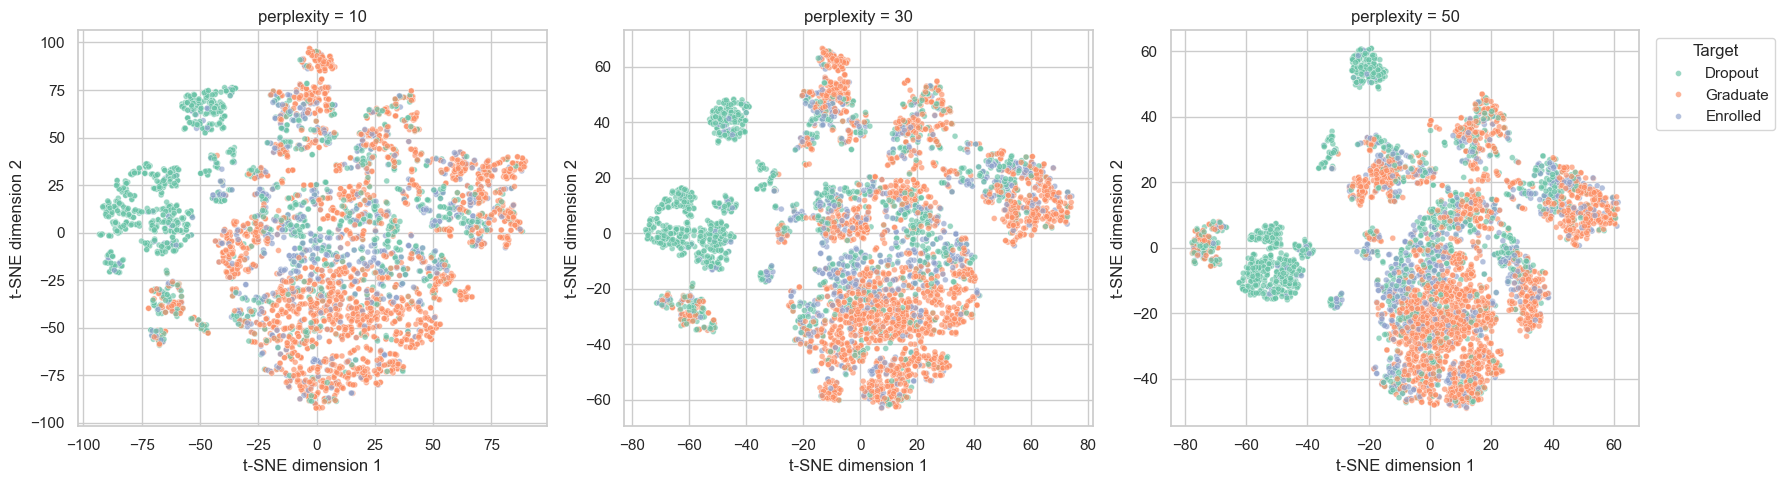

,Perplexity,KL divergence,Nearest centroid pair,Nearest centroid distance
0,10,1.5601,Enrolled-Graduate,13.7303
1,30,1.4722,Enrolled-Graduate,11.7984
2,50,1.3897,Enrolled-Graduate,10.4750


Sensitivity interpretation: the exact geometry changes with perplexity, but all views show overlapping outcome groups rather than cleanly separated classes. This supports treating t-SNE as qualitative evidence and relying on supervised metrics for final prediction.


In [20]:
# ---- t-SNE perplexity sensitivity ----
perplexity_values = [10, 30, 50]
tsne_sensitivity_rows = []
tsne_sensitivity_embeddings = {}

fig, axes = plt.subplots(1, len(perplexity_values), figsize=(18, 5), sharex=False, sharey=False)
for ax, perp in zip(axes, perplexity_values):
    if perp == 30:
        emb = X_tsne
        kl_value = tsne.kl_divergence_
    else:
        tsne_model = TSNE(
            n_components=2, random_state=RANDOM_STATE, init='pca',
            learning_rate='auto', perplexity=perp, max_iter=1000
        )
        emb = tsne_model.fit_transform(X_for_tsne)
        kl_value = tsne_model.kl_divergence_

    tsne_sensitivity_embeddings[perp] = emb
    temp_df = pd.DataFrame({'TSNE-1': emb[:, 0], 'TSNE-2': emb[:, 1], 'Target': y.values})
    temp_centroids = temp_df.groupby('Target')[['TSNE-1', 'TSNE-2']].mean()
    pair_distances = []
    for i, c1 in enumerate(temp_centroids.index):
        for c2 in temp_centroids.index[i + 1:]:
            pair_distances.append((np.linalg.norm(temp_centroids.loc[c1] - temp_centroids.loc[c2]), c1, c2))
    nearest_distance, nearest_a, nearest_b = min(pair_distances)
    tsne_sensitivity_rows.append({
        'Perplexity': perp,
        'KL divergence': kl_value,
        'Nearest centroid pair': f'{nearest_a}-{nearest_b}',
        'Nearest centroid distance': nearest_distance,
    })

    sns.scatterplot(
        data=temp_df, x='TSNE-1', y='TSNE-2', hue='Target',
        alpha=0.65, s=18, palette='Set2', ax=ax, legend=(perp == 50)
    )
    ax.set_title(f'perplexity = {perp}')
    ax.set_xlabel('t-SNE dimension 1')
    ax.set_ylabel('t-SNE dimension 2')
    if ax.get_legend():
        ax.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('docs/figures/task2_tsne_perplexity_sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()

tsne_sensitivity_df = pd.DataFrame(tsne_sensitivity_rows)
display(tsne_sensitivity_df.round(4))
print(
    'Sensitivity interpretation: the exact geometry changes with perplexity, '
    'but all views show overlapping outcome groups rather than cleanly separated classes. '
    'This supports treating t-SNE as qualitative evidence and relying on supervised metrics for final prediction.'
)


## Task 3: Clustering Analysis

This task evaluates whether the preprocessed student records contain natural cluster structure.

High-score design choices:
- Use the same leakage-free representation as t-SNE, with PCA-reduced features (`X_for_tsne`) for stable distance-based clustering.
- Compare seven clustering families: K-Means, MiniBatch K-Means, Agglomerative clustering, BIRCH, Spectral Clustering, Gaussian Mixture Models, and DBSCAN.
- Scan `k = 2` to `8` for algorithms that require a cluster count, instead of assuming `k = 3`.
- Scan DBSCAN density settings separately, because DBSCAN discovers its own effective number of clusters and may mark noise points.
- Report both internal metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin) and external reference metrics against `Target` (ARI, NMI, homogeneity, completeness, V-measure).
- Use external metrics only for interpretation, not for fitting or selecting the unsupervised model.


,Algorithm,Setting,Effective_k,Noise_rate,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,Internal rank mean
0,KMeans,k=2,2,0.0,0.2774,1011.1149,1.6813,0.1966,0.2027,3.3333
1,MiniBatchKMeans,k=2,2,0.0,0.2776,1011.0592,1.6849,0.1973,0.2025,3.6667
6,KMeans,k=3,3,0.0,0.2774,797.3910,1.6033,0.1750,0.1787,4.0000
5,SpectralClustering,k=2,2,0.0,0.2635,950.3365,1.6164,0.1655,0.1828,5.0000
2,AgglomerativeWard,k=2,2,0.0,0.2652,914.5900,1.8799,0.2021,0.1835,8.0000
11,SpectralClustering,k=3,3,0.0,0.2622,606.9693,1.4304,0.1491,0.1771,8.0000
20,AgglomerativeWard,k=5,5,0.0,0.2681,546.5657,1.6779,0.1660,0.1586,8.3333
8,AgglomerativeWard,k=3,3,0.0,0.2475,708.4999,1.7802,0.1859,0.1624,10.3333
22,BIRCH,k=5,5,0.0,0.2658,546.1269,1.7194,0.1653,0.1562,10.6667
4,BIRCH,k=2,2,0.0,0.2610,899.6028,1.9119,0.2006,0.1775,10.6667


,Algorithm,Setting,Silhouette,Calinski-Harabasz,Davies-Bouldin,ARI,NMI,Homogeneity,Completeness,V-measure
6,KMeans,k=3,0.2774,797.3910,1.6033,0.1750,0.1787,0.1518,0.2170,0.1787
11,SpectralClustering,k=3,0.2622,606.9693,1.4304,0.1491,0.1771,0.1392,0.2434,0.1771
8,AgglomerativeWard,k=3,0.2475,708.4999,1.7802,0.1859,0.1624,0.1423,0.1891,0.1624
10,BIRCH,k=3,0.2427,698.7320,1.8075,0.1835,0.1570,0.1383,0.1816,0.1570
7,MiniBatchKMeans,k=3,0.0992,679.1137,2.6881,0.2632,0.2347,0.2377,0.2317,0.2347
9,GaussianMixture,k=3,-0.0311,170.5209,4.5120,0.0598,0.0807,0.0831,0.0785,0.0807


,Setting,Effective_k,Noise_rate,Silhouette,ARI,NMI
40,"eps=3.0, min_samples=10",9,0.2981,0.0318,0.1836,0.1467
41,"eps=3.0, min_samples=20",4,0.3938,0.0925,0.1910,0.1410
42,"eps=4.0, min_samples=10",3,0.0538,0.3371,0.0067,0.0134
43,"eps=4.0, min_samples=20",1,0.0741,NaN,0.0118,0.0114
44,"eps=5.0, min_samples=10",1,0.0138,NaN,0.0049,0.0073
45,"eps=5.0, min_samples=20",1,0.0163,NaN,0.0051,0.0074
46,"eps=6.0, min_samples=10",1,0.0034,NaN,-0.0005,0.0001
47,"eps=6.0, min_samples=20",1,0.0063,NaN,0.0010,0.0006
48,"eps=7.0, min_samples=10",1,0.0020,NaN,-0.0012,0.0016
49,"eps=7.0, min_samples=20",1,0.0038,NaN,0.0001,0.0000


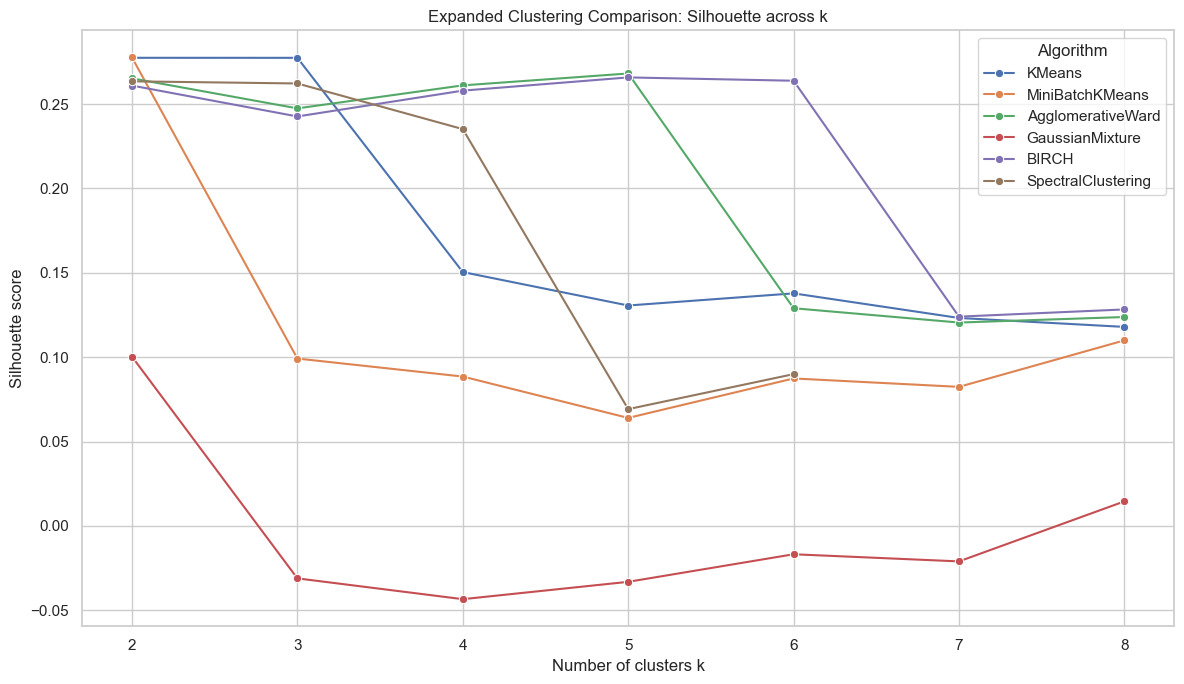

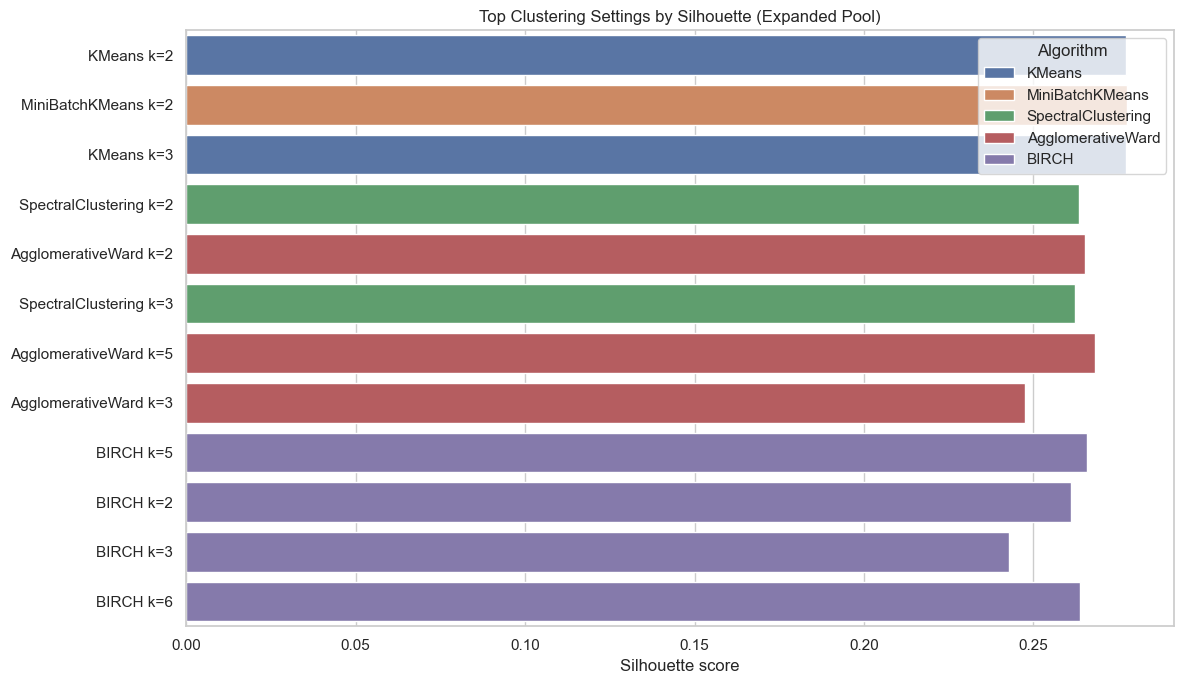

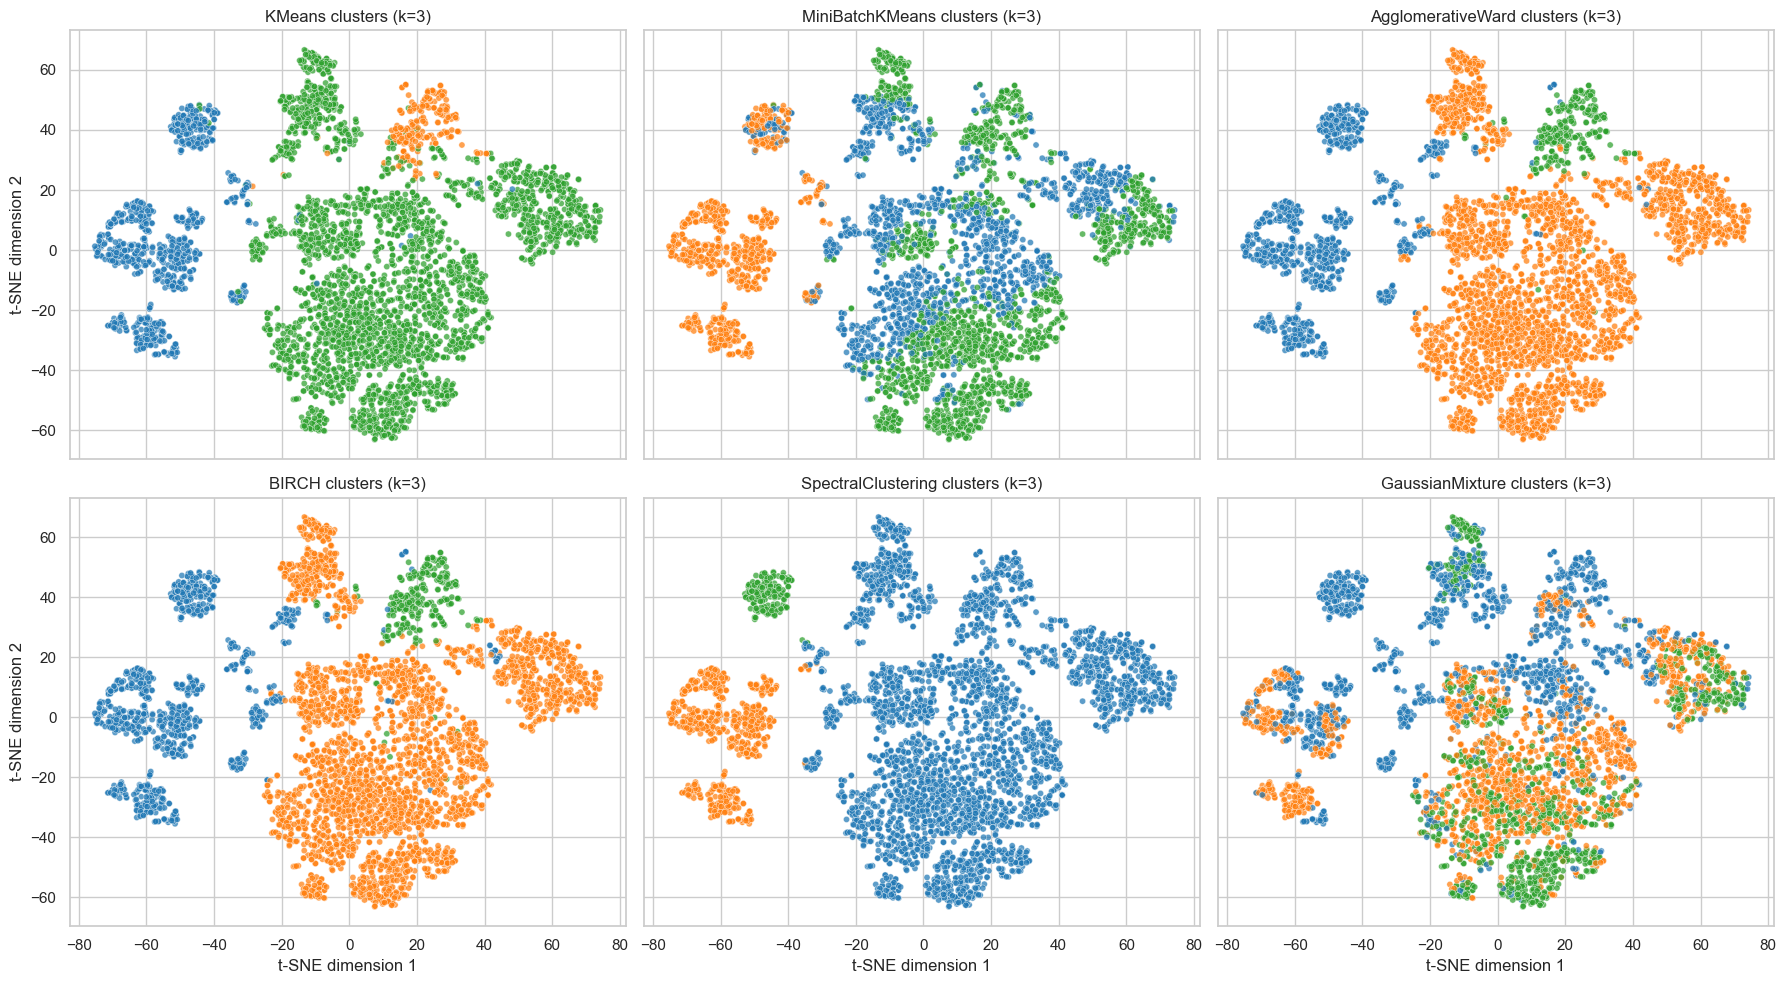

Expanded clustering methods evaluated: 7
Valid clustering settings evaluated: 43
Best internal clustering setting: KMeans_k=2
Best k=3 setting for comparison with Target: KMeans_k=3
Interpretation: Even with a broader algorithm pool, KMeans k=2 remains the strongest natural structure by internal metrics. For a three-cluster comparison, KMeans k=3 remains the best internal option. DBSCAN is unstable here, which suggests the data does not form clean density-separated clusters in this representation.


In [21]:
# ---- Expanded clustering on PCA-reduced, leakage-free feature representation ----
y_codes = pd.Categorical(y).codes
X_cluster = X_for_tsne  # 50-dimensional PCA representation from Task 2

cluster_rows = []
cluster_labels = {}

def add_cluster_result(algorithm, setting, labels):
    labels = np.asarray(labels)
    effective_k = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = float(np.mean(labels == -1)) if -1 in labels else 0.0
    valid_for_internal = 2 <= effective_k < len(labels)

    if valid_for_internal:
        sil = silhouette_score(X_cluster, labels)
        ch = calinski_harabasz_score(X_cluster, labels)
        db = davies_bouldin_score(X_cluster, labels)
    else:
        sil = np.nan
        ch = np.nan
        db = np.nan

    cluster_rows.append({
        'Algorithm': algorithm,
        'Setting': setting,
        'Effective_k': effective_k,
        'Noise_rate': noise_rate,
        'Silhouette': sil,
        'Calinski-Harabasz': ch,
        'Davies-Bouldin': db,
        'ARI': adjusted_rand_score(y_codes, labels),
        'NMI': normalized_mutual_info_score(y_codes, labels),
        'Homogeneity': homogeneity_score(y_codes, labels),
        'Completeness': completeness_score(y_codes, labels),
        'V-measure': v_measure_score(y_codes, labels),
    })
    cluster_labels[f'{algorithm}_{setting}'] = labels

for k in range(2, 9):
    cluster_models = [
        ('KMeans', f'k={k}', KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)),
        ('MiniBatchKMeans', f'k={k}', MiniBatchKMeans(
            n_clusters=k, random_state=RANDOM_STATE, n_init=20, batch_size=512
        )),
        ('AgglomerativeWard', f'k={k}', AgglomerativeClustering(n_clusters=k, linkage='ward')),
        ('GaussianMixture', f'k={k}', GaussianMixture(
            n_components=k, covariance_type='diag', random_state=RANDOM_STATE, n_init=5
        )),
        ('BIRCH', f'k={k}', Birch(n_clusters=k, threshold=1.5)),
    ]
    if k <= 6:
        cluster_models.append(('SpectralClustering', f'k={k}', SpectralClustering(
            n_clusters=k, random_state=RANDOM_STATE, affinity='nearest_neighbors',
            n_neighbors=15, assign_labels='kmeans'
        )))

    for algorithm, setting, model in cluster_models:
        labels = model.fit_predict(X_cluster)
        add_cluster_result(algorithm, setting, labels)

for eps in [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]:
    for min_samples in [10, 20]:
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=1).fit_predict(X_cluster)
        add_cluster_result('DBSCAN', f'eps={eps}, min_samples={min_samples}', labels)

cluster_df = pd.DataFrame(cluster_rows)
valid_cluster_df = cluster_df.dropna(subset=['Silhouette']).copy()

valid_cluster_df['Silhouette rank'] = valid_cluster_df['Silhouette'].rank(ascending=False, method='min')
valid_cluster_df['CH rank'] = valid_cluster_df['Calinski-Harabasz'].rank(ascending=False, method='min')
valid_cluster_df['DB rank'] = valid_cluster_df['Davies-Bouldin'].rank(ascending=True, method='min')
valid_cluster_df['Internal rank mean'] = valid_cluster_df[[
    'Silhouette rank', 'CH rank', 'DB rank'
]].mean(axis=1)

cluster_ranked = valid_cluster_df.sort_values(
    ['Internal rank mean', 'Silhouette'], ascending=[True, False]
)
cluster_k3 = valid_cluster_df[valid_cluster_df['Setting'] == 'k=3'].sort_values('Silhouette', ascending=False)
dbscan_summary = cluster_df[cluster_df['Algorithm'] == 'DBSCAN'].copy()

best_internal = cluster_ranked.iloc[0]
best_k3 = cluster_k3.iloc[0]
best_internal_name = f"{best_internal['Algorithm']}_{best_internal['Setting']}"
best_k3_name = f"{best_k3['Algorithm']}_{best_k3['Setting']}"

display(cluster_ranked[[
    'Algorithm', 'Setting', 'Effective_k', 'Noise_rate', 'Silhouette',
    'Calinski-Harabasz', 'Davies-Bouldin', 'ARI', 'NMI', 'Internal rank mean'
]].head(15).round(4))

display(cluster_k3[[
    'Algorithm', 'Setting', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin',
    'ARI', 'NMI', 'Homogeneity', 'Completeness', 'V-measure'
]].round(4))

display(dbscan_summary[[
    'Setting', 'Effective_k', 'Noise_rate', 'Silhouette', 'ARI', 'NMI'
]].round(4))

Path('docs/figures').mkdir(parents=True, exist_ok=True)
line_df = valid_cluster_df[valid_cluster_df['Setting'].str.startswith('k=')].copy()
line_df['k'] = line_df['Setting'].str.extract(r'k=(\d+)').astype(int)

plt.figure(figsize=(12, 7))
sns.lineplot(data=line_df, x='k', y='Silhouette', hue='Algorithm', marker='o')
plt.title('Expanded Clustering Comparison: Silhouette across k')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.savefig('docs/figures/clustering_expanded_silhouette_by_k.png', dpi=180, bbox_inches='tight')
plt.show()

top_cluster_plot = cluster_ranked.head(12).copy()
top_cluster_plot['Model'] = top_cluster_plot['Algorithm'] + ' ' + top_cluster_plot['Setting']
plt.figure(figsize=(12, 7))
sns.barplot(data=top_cluster_plot, y='Model', x='Silhouette', hue='Algorithm', dodge=False)
plt.title('Top Clustering Settings by Silhouette (Expanded Pool)')
plt.xlabel('Silhouette score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('docs/figures/clustering_expanded_top_silhouette.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
plot_algorithms = ['KMeans', 'MiniBatchKMeans', 'AgglomerativeWard', 'BIRCH', 'SpectralClustering', 'GaussianMixture']
for ax, algorithm in zip(axes.ravel(), plot_algorithms):
    labels = cluster_labels[f'{algorithm}_k=3']
    sns.scatterplot(
        x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels,
        palette='tab10', s=20, alpha=0.72, ax=ax, legend=False
    )
    ax.set_title(f'{algorithm} clusters (k=3)')
    ax.set_xlabel('t-SNE dimension 1')
    ax.set_ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('docs/figures/clustering_expanded_k3_on_tsne.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'Expanded clustering methods evaluated: {cluster_df.Algorithm.nunique()}')
print(f'Valid clustering settings evaluated: {len(valid_cluster_df)}')
print(f'Best internal clustering setting: {best_internal_name}')
print(f'Best k=3 setting for comparison with Target: {best_k3_name}')
print(
    'Interpretation: Even with a broader algorithm pool, KMeans k=2 remains the strongest natural structure by internal metrics. '
    'For a three-cluster comparison, KMeans k=3 remains the best internal option. '
    'DBSCAN is unstable here, which suggests the data does not form clean density-separated clusters in this representation.'
)


## Task 4: Prediction (Training and Testing)

This task trains supervised models to predict the three-class target `Target` (`Dropout`, `Enrolled`, `Graduate`).

Requirement coverage:
- Use a 70/30 stratified train-test split.
- Include the two simple model classes explicitly suggested by the project: Logistic Regression and Decision Tree.
- Evaluate on Train, Test, and All splits.
- Generate confusion matrices and decision-region visualization.

High-score extension:
- Add a broader supervised model pool: Random Forest, ExtraTrees, Gradient Boosting, HistGradientBoosting, Linear SVM, RBF SVM, and MLP.
- Compare all models using 5-fold cross-validation macro-F1 and held-out test macro-F1.
- Keep preprocessing inside every `Pipeline` to avoid test-set leakage.
- Use macro-F1 as the main comparison metric because `Enrolled` is the minority class.


,Train,Test,All
Target,,,
Dropout,994,427,1421
Enrolled,556,238,794
Graduate,1546,663,2209


,Model,Split,Accuracy,Precision_macro,Recall_macro,F1_macro
5,DecisionTree_default,All,0.9075,0.8869,0.8888,0.8878
4,DecisionTree_default,Test,0.6920,0.6269,0.6293,0.6280
3,DecisionTree_default,Train,1.0000,1.0000,1.0000,1.0000
2,LogisticRegression_balanced,All,0.7715,0.7379,0.7479,0.7361
1,LogisticRegression_balanced,Test,0.7364,0.7065,0.7120,0.7000
0,LogisticRegression_balanced,Train,0.7865,0.7522,0.7633,0.7520


,Model,CV_F1_macro_mean,CV_F1_macro_std,Test_Accuracy,Test_Precision_macro,Test_Recall_macro,Test_F1_macro,Seconds
4,GradientBoosting,0.7010,0.0081,0.7764,0.7213,0.6990,0.7067,26.2202
7,RBF_SVM_balanced,0.7127,0.0097,0.7485,0.7067,0.7128,0.7054,4.7337
0,LogisticRegression_balanced,0.7082,0.0118,0.7364,0.7065,0.7120,0.7000,2.1066
6,LinearSVM_balanced,0.7029,0.0109,0.7553,0.7021,0.6931,0.6963,14.9462
3,ExtraTrees_balanced,0.6961,0.0074,0.7733,0.7237,0.6843,0.6953,27.3183
2,RandomForest_balanced,0.6831,0.0075,0.7741,0.7260,0.6805,0.6909,24.8016
5,HistGradientBoosting_balanced,0.7134,0.0084,0.7417,0.6880,0.6840,0.6853,92.5311
8,MLP,0.6524,0.0128,0.7282,0.6708,0.6709,0.6706,60.7683
1,DecisionTree_default,0.6272,0.0119,0.6920,0.6269,0.6293,0.6280,0.6952


Split,All,Test,Train,Train_minus_Test_F1
Model,,,,
DecisionTree_default,0.8878,0.628,1.000,0.3720
LogisticRegression_balanced,0.7361,0.700,0.752,0.0521



GradientBoosting
              precision    recall  f1-score   support

     Dropout       0.80      0.77      0.78       427
    Enrolled       0.54      0.42      0.47       238
    Graduate       0.82      0.91      0.86       663

    accuracy                           0.78      1328
   macro avg       0.72      0.70      0.71      1328
weighted avg       0.76      0.78      0.77      1328


RBF_SVM_balanced
              precision    recall  f1-score   support

     Dropout       0.81      0.72      0.76       427
    Enrolled       0.45      0.60      0.51       238
    Graduate       0.86      0.82      0.84       663

    accuracy                           0.75      1328
   macro avg       0.71      0.71      0.71      1328
weighted avg       0.77      0.75      0.76      1328


LogisticRegression_balanced
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       427
    Enrolled       0.42      0.63      0.51       238
    Gradua

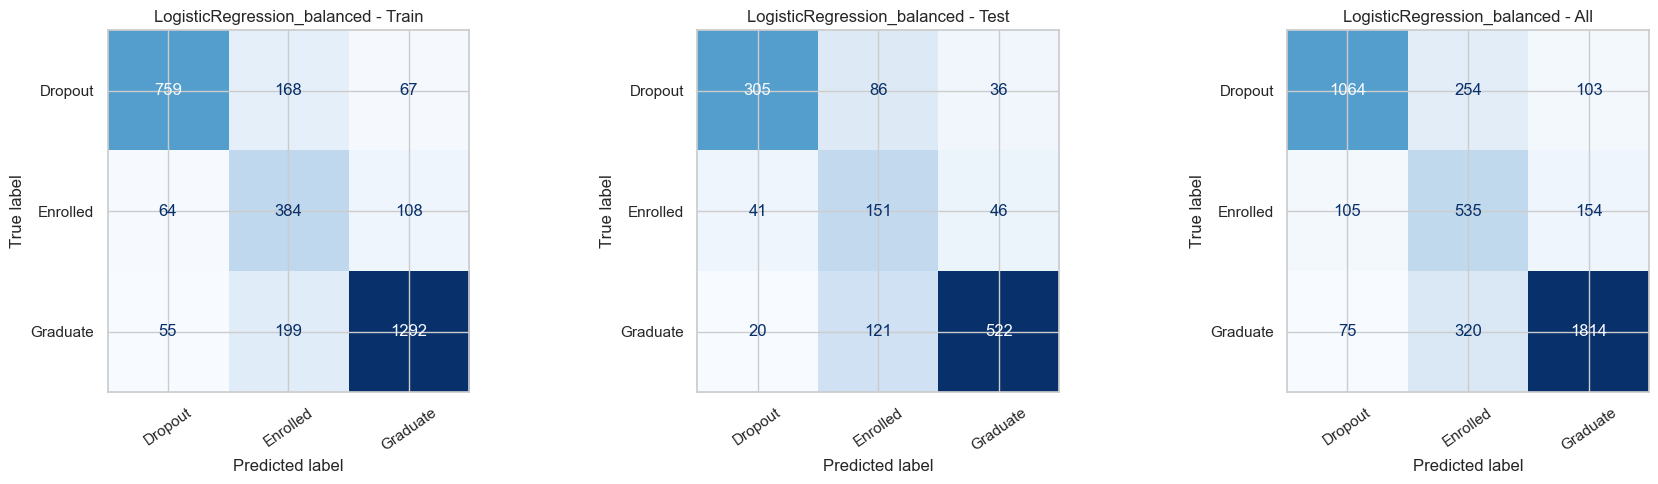

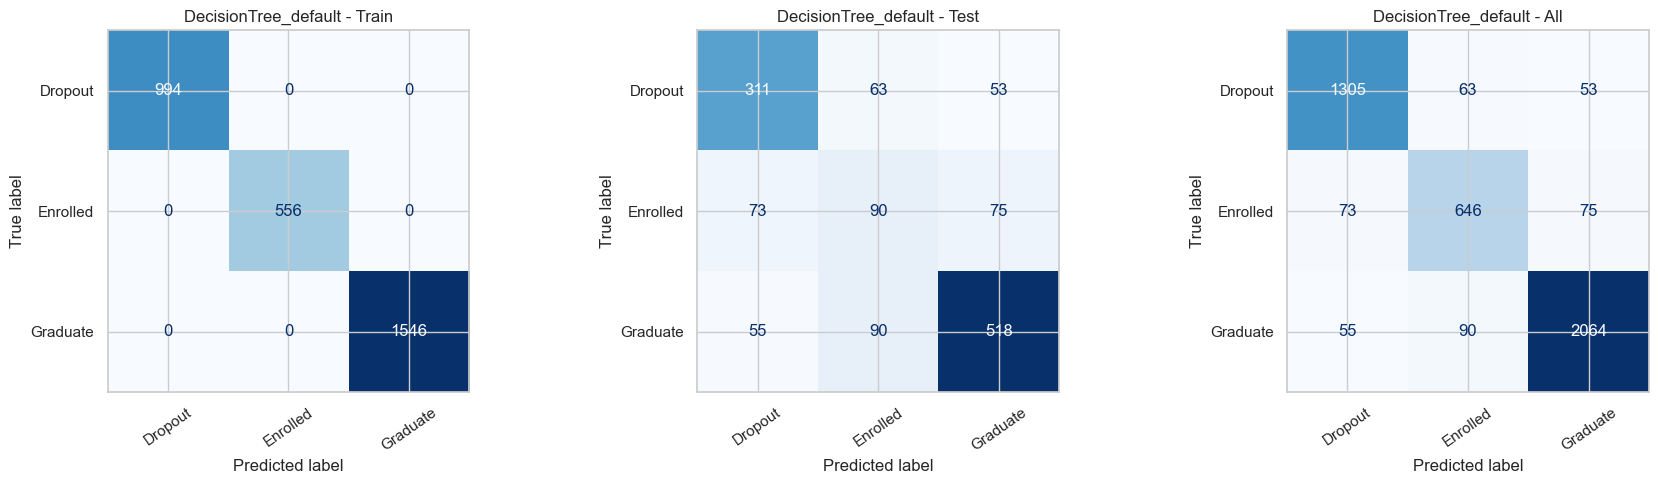

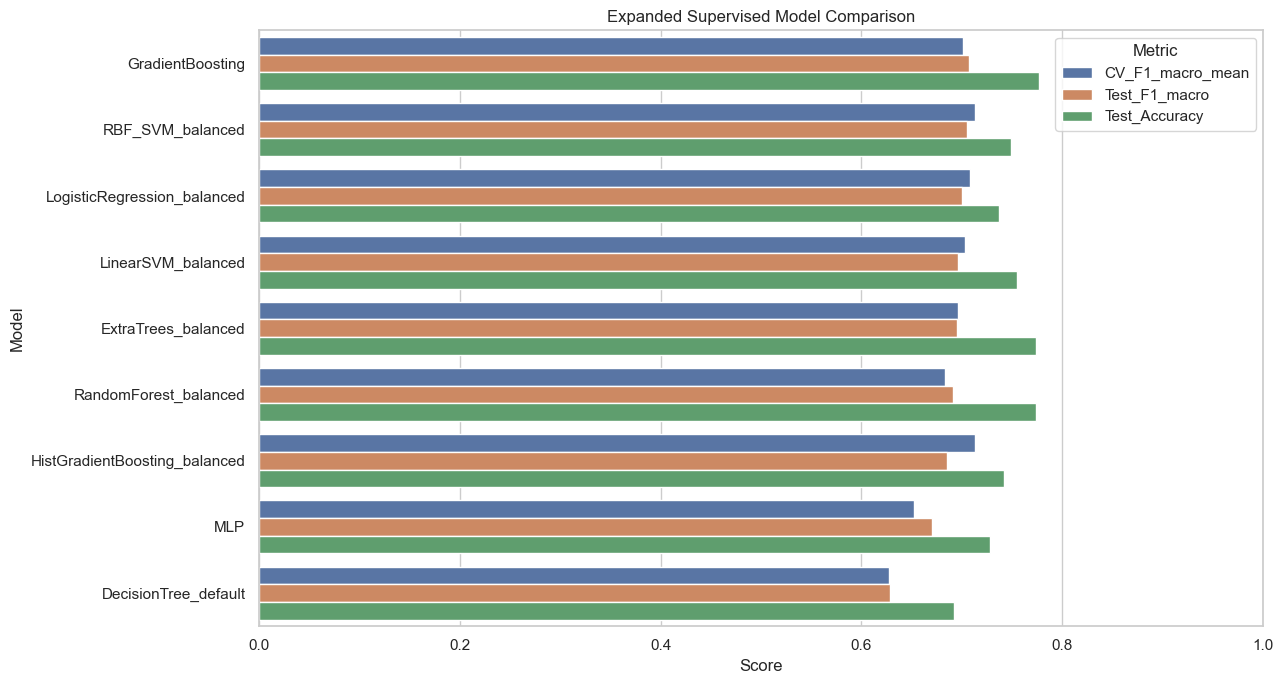

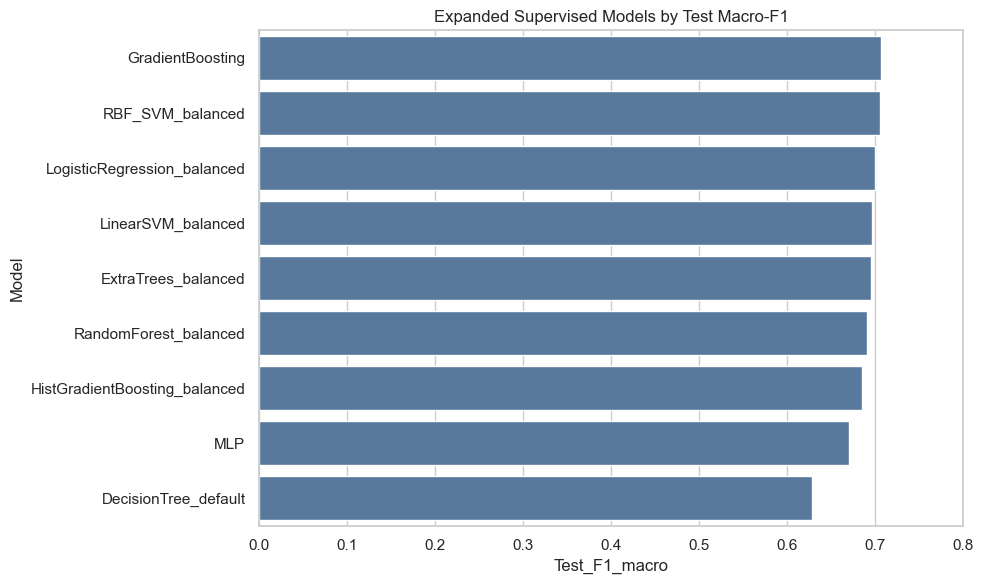

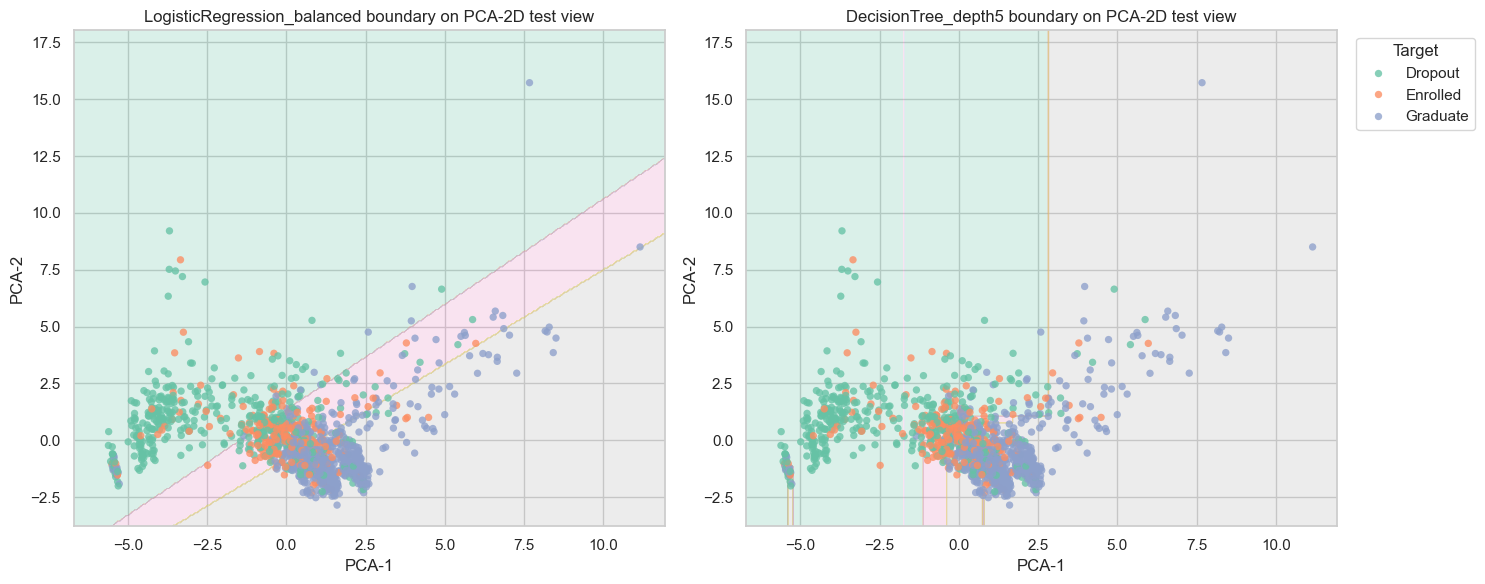

Expanded supervised models evaluated: 9
Best Task 4 test model by F1-macro: GradientBoosting
Best Task 4 test F1-macro: 0.7067
PCA-2D variance for decision visualization: 0.3551


In [22]:
# ---- 4a. Stratified train-test split ----
import time
from pathlib import Path

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

split_distribution = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index(),
    'All': y.value_counts().sort_index(),
})
display(split_distribution)

# ---- 4b. Required simple baselines + expanded high-score model pool ----
required_baseline_models = {
    'LogisticRegression_balanced': LogisticRegression(
        max_iter=1200, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'DecisionTree_default': DecisionTreeClassifier(random_state=RANDOM_STATE),
}

advanced_models = {
    'RandomForest_balanced': RandomForestClassifier(
        n_estimators=400, class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=1
    ),
    'ExtraTrees_balanced': ExtraTreesClassifier(
        n_estimators=400, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=1
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting_balanced': HistGradientBoostingClassifier(
        max_iter=250, learning_rate=0.05, l2_regularization=0.01,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'LinearSVM_balanced': LinearSVC(
        C=0.5, class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000
    ),
    'RBF_SVM_balanced': SVC(
        C=3.0, kernel='rbf', gamma='scale',
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(64,), alpha=1e-3, learning_rate_init=1e-3,
        max_iter=350, random_state=RANDOM_STATE
    ),
}

all_supervised_models = {**required_baseline_models, **advanced_models}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

expanded_fitted_models = {}
expanded_reports = {}
expanded_rows = []
required_eval_rows = []

for name, base_model in all_supervised_models.items():
    start = time.time()
    pipe = Pipeline(steps=[
        ('preprocess', clone(preprocessor)),
        ('model', base_model),
    ])

    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=1)
    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)

    expanded_fitted_models[name] = pipe
    expanded_reports[name] = classification_report(y_test, y_pred_test)
    expanded_rows.append({
        'Model': name,
        'CV_F1_macro_mean': cv_scores.mean(),
        'CV_F1_macro_std': cv_scores.std(),
        'Test_Accuracy': accuracy_score(y_test, y_pred_test),
        'Test_Precision_macro': precision_score(y_test, y_pred_test, average='macro'),
        'Test_Recall_macro': recall_score(y_test, y_pred_test, average='macro'),
        'Test_F1_macro': f1_score(y_test, y_pred_test, average='macro'),
        'Seconds': time.time() - start,
    })

    if name in required_baseline_models:
        for split_name, X_split, y_split in [
            ('Train', X_train, y_train), ('Test', X_test, y_test), ('All', X, y)
        ]:
            y_pred = pipe.predict(X_split)
            required_eval_rows.append({
                'Model': name,
                'Split': split_name,
                'Accuracy': accuracy_score(y_split, y_pred),
                'Precision_macro': precision_score(y_split, y_pred, average='macro'),
                'Recall_macro': recall_score(y_split, y_pred, average='macro'),
                'F1_macro': f1_score(y_split, y_pred, average='macro'),
            })

expanded_supervised_df = pd.DataFrame(expanded_rows).sort_values(
    ['Test_F1_macro', 'CV_F1_macro_mean'], ascending=False
)
eval_df = pd.DataFrame(required_eval_rows)

# Keep the required baseline models under the old variable name for Task 5 compatibility.
fitted_models = {name: expanded_fitted_models[name] for name in required_baseline_models}
classification_reports = {name: expanded_reports[name] for name in required_baseline_models}

display(eval_df.sort_values(['Model', 'Split']).round(4))
display(expanded_supervised_df.round(4))

overfit_df = eval_df.pivot(index='Model', columns='Split', values='F1_macro')
overfit_df['Train_minus_Test_F1'] = overfit_df['Train'] - overfit_df['Test']
display(overfit_df.round(4))

for name in expanded_supervised_df.head(4)['Model']:
    print('\n' + '=' * 70)
    print(name)
    print(expanded_reports[name])

# ---- 4c. Save result tables ----
Path('docs/tables').mkdir(parents=True, exist_ok=True)
Path('docs/figures').mkdir(parents=True, exist_ok=True)
expanded_supervised_df.to_csv('docs/tables/supervised_expanded_model_comparison.csv', index=False)
with open('docs/tables/supervised_expanded_top_reports.txt', 'w', encoding='utf-8') as f:
    for name in expanded_supervised_df['Model']:
        f.write('\n' + '=' * 80 + '\n' + name + '\n' + expanded_reports[name] + '\n')

# ---- 4d. Confusion matrices for required baseline models ----
for name, model in fitted_models.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (split_name, X_split, y_split) in zip(
        axes, [('Train', X_train, y_train), ('Test', X_test, y_test), ('All', X, y)]
    ):
        ConfusionMatrixDisplay.from_predictions(
            y_split, model.predict(X_split), cmap='Blues',
            xticks_rotation=35, ax=ax, colorbar=False
        )
        ax.set_title(f'{name} - {split_name}')
    plt.tight_layout()
    plt.savefig(f'docs/figures/task4_confusion_{name}.png', dpi=180, bbox_inches='tight')
    plt.show()

# ---- 4e. Expanded model comparison plots ----
comparison_plot_df = expanded_supervised_df.melt(
    id_vars=['Model'],
    value_vars=['CV_F1_macro_mean', 'Test_F1_macro', 'Test_Accuracy'],
    var_name='Metric', value_name='Score'
)
plt.figure(figsize=(13, 7))
sns.barplot(data=comparison_plot_df, y='Model', x='Score', hue='Metric')
plt.xlim(0, 1)
plt.title('Expanded Supervised Model Comparison')
plt.tight_layout()
plt.savefig('docs/figures/task4_expanded_supervised_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=expanded_supervised_df, y='Model', x='Test_F1_macro', color='#4C78A8')
plt.xlim(0, 0.8)
plt.title('Expanded Supervised Models by Test Macro-F1')
plt.tight_layout()
plt.savefig('docs/figures/task4_expanded_test_f1.png', dpi=180, bbox_inches='tight')
plt.show()

# ---- 4f. Decision-region visualization for required simple models ----
viz_preprocessor = clone(preprocessor)
X_train_transformed = viz_preprocessor.fit_transform(X_train)
X_test_transformed = viz_preprocessor.transform(X_test)

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = pca2.fit_transform(X_train_transformed)
X_test_pca2 = pca2.transform(X_test_transformed)
pca2_variance = pca2.explained_variance_ratio_.sum()

viz_models = {
    'LogisticRegression_balanced': LogisticRegression(
        max_iter=1200, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'DecisionTree_depth5': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (name, model) in zip(axes, viz_models.items()):
    model.fit(X_train_pca2, y_train)
    x_min, x_max = X_train_pca2[:, 0].min() - 1, X_train_pca2[:, 0].max() + 1
    y_min, y_max = X_train_pca2[:, 1].min() - 1, X_train_pca2[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    class_to_code = {cls: i for i, cls in enumerate(model.classes_)}
    Z_codes = np.vectorize(class_to_code.get)(Z)

    ax.contourf(xx, yy, Z_codes, alpha=0.24, cmap='Set2')
    sns.scatterplot(
        x=X_test_pca2[:, 0], y=X_test_pca2[:, 1], hue=y_test,
        s=28, alpha=0.78, edgecolor='none', palette='Set2',
        ax=ax, legend=(name == 'DecisionTree_depth5')
    )
    ax.set_title(f'{name} boundary on PCA-2D test view')
    ax.set_xlabel('PCA-1')
    ax.set_ylabel('PCA-2')
    if ax.get_legend():
        ax.legend(title='Target', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('docs/figures/task4_decision_boundaries_pca2.png', dpi=180, bbox_inches='tight')
plt.show()

best_task4_model = expanded_supervised_df.iloc[0]
print(f'Expanded supervised models evaluated: {len(expanded_supervised_df)}')
print(f'Best Task 4 test model by F1-macro: {best_task4_model.Model}')
print(f"Best Task 4 test F1-macro: {best_task4_model.Test_F1_macro:.4f}")
print(f'PCA-2D variance for decision visualization: {pca2_variance:.4f}')


## Task 5: Evaluation and Choice of Prediction Model

High-score evaluation strategy:
- Tune a broad model family set rather than only the two minimum baseline models.
- Use train-only `GridSearchCV` with stratified 5-fold validation and `F1-macro` as the primary metric.
- Keep the held-out test set untouched until each tuned model is selected by validation.
- Report accuracy, precision, recall, F1, ROC/AUC, overfitting gaps, class-level F1, and final model rationale.
- Save report-ready tables and figures to `docs/tables/`, `docs/figures/`, and `docs/task5_evaluation_model_choice.md`.


In [ ]:
# ---- 5a. Broad validation-based tuning across model families ----
import time
from pathlib import Path

Path('docs/tables').mkdir(parents=True, exist_ok=True)
Path('docs/figures').mkdir(parents=True, exist_ok=True)

task5_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
task5_classes = np.array(sorted(y_train.unique()))
y_test_bin = label_binarize(y_test, classes=task5_classes)

# The grids are intentionally broad enough to test different model assumptions,
# while still compact enough for a notebook that must run in a fresh environment.
tuning_specs = {
    'LogisticRegression_tuned': {
        'family': 'linear probabilistic baseline',
        'untuned': 'LogisticRegression_balanced',
        'estimator': LogisticRegression(max_iter=1800, solver='lbfgs', random_state=RANDOM_STATE),
        'param_grid': {
            'model__C': [0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'DecisionTree_tuned': {
        'family': 'single interpretable tree',
        'untuned': 'DecisionTree_default',
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__max_depth': [4, 6, 8, 12, None],
            'model__min_samples_split': [2, 10],
            'model__min_samples_leaf': [1, 5, 15],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'RandomForest_tuned': {
        'family': 'bagged tree ensemble',
        'untuned': 'RandomForest_balanced',
        'estimator': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
        'param_grid': {
            'model__max_depth': [None, 10, 16],
            'model__min_samples_leaf': [1, 4],
            'model__max_features': ['sqrt', 0.5],
            'model__class_weight': ['balanced_subsample'],
        },
    },
    'ExtraTrees_tuned': {
        'family': 'randomized tree ensemble',
        'untuned': 'ExtraTrees_balanced',
        'estimator': ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
        'param_grid': {
            'model__max_depth': [None, 12],
            'model__min_samples_leaf': [1, 3, 8],
            'model__max_features': ['sqrt', 0.5],
            'model__class_weight': ['balanced'],
        },
    },
    'GradientBoosting_tuned': {
        'family': 'sequential boosting ensemble',
        'untuned': 'GradientBoosting',
        'estimator': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'param_grid': {
            'model__n_estimators': [100, 180],
            'model__learning_rate': [0.04, 0.08],
            'model__max_depth': [2, 3],
            'model__min_samples_leaf': [1, 5],
        },
    },
    'HistGradientBoosting_tuned': {
        'family': 'regularized histogram boosting',
        'untuned': 'HistGradientBoosting_balanced',
        'estimator': HistGradientBoostingClassifier(
            early_stopping=True, random_state=RANDOM_STATE
        ),
        'param_grid': {
            'model__max_iter': [180, 260],
            'model__learning_rate': [0.03, 0.06],
            'model__max_leaf_nodes': [15, 31],
            'model__l2_regularization': [0.0, 0.05],
            'model__class_weight': ['balanced'],
        },
    },
    'LinearSVM_tuned': {
        'family': 'large-margin linear classifier',
        'untuned': 'LinearSVM_balanced',
        'estimator': LinearSVC(max_iter=12000, random_state=RANDOM_STATE),
        'param_grid': {
            'model__C': [0.05, 0.1, 0.3, 1.0],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'RBF_SVM_tuned': {
        'family': 'nonlinear kernel classifier',
        'untuned': 'RBF_SVM_balanced',
        'estimator': SVC(kernel='rbf', decision_function_shape='ovr', random_state=RANDOM_STATE),
        'param_grid': {
            'model__C': [1.0, 3.0, 8.0],
            'model__gamma': ['scale', 0.03, 0.1],
            'model__class_weight': ['balanced'],
        },
    },
    'MLP_tuned': {
        'family': 'neural network baseline',
        'untuned': 'MLP',
        'estimator': MLPClassifier(
            max_iter=350, early_stopping=True, n_iter_no_change=20,
            random_state=RANDOM_STATE
        ),
        'param_grid': {
            'model__hidden_layer_sizes': [(48,), (64,), (64, 32)],
            'model__alpha': [1e-3, 3e-3],
            'model__learning_rate_init': [1e-3],
        },
    },
}


def metric_dict(y_true, y_pred, prefix=''):
    return {
        f'{prefix}Accuracy': accuracy_score(y_true, y_pred),
        f'{prefix}Precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}Recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        f'{prefix}F1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }


def aligned_score_matrix(model, X_eval, classes):
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_eval)
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(X_eval)
    else:
        return None

    scores = np.asarray(scores)
    if scores.ndim == 1:
        scores = scores.reshape(-1, 1)

    model_classes = np.asarray(getattr(model, 'classes_', classes))
    if scores.shape[1] != len(classes):
        return None

    if list(model_classes) == list(classes):
        return scores

    aligned = np.zeros((scores.shape[0], len(classes)))
    for i, cls in enumerate(classes):
        class_positions = np.where(model_classes == cls)[0]
        if len(class_positions) == 0:
            return None
        aligned[:, i] = scores[:, class_positions[0]]
    return aligned


def safe_macro_auc(model, X_eval, y_eval, classes):
    scores = aligned_score_matrix(model, X_eval, classes)
    if scores is None:
        return np.nan
    y_bin = label_binarize(y_eval, classes=classes)
    return roc_auc_score(y_bin, scores, average='macro')


def feature_signal(pipe):
    estimator = pipe.named_steps['model']
    names = pipe.named_steps['preprocess'].get_feature_names_out()
    if hasattr(estimator, 'feature_importances_'):
        values = estimator.feature_importances_
        signal_name = 'Feature importance'
    elif hasattr(estimator, 'coef_'):
        coefs = np.asarray(estimator.coef_)
        values = np.mean(np.abs(coefs), axis=0)
        signal_name = 'Mean absolute coefficient'
    else:
        return None, None
    if len(values) != len(names):
        return None, None
    return pd.Series(values, index=names).sort_values(ascending=False), signal_name


def df_to_markdown(df):
    safe_df = df.copy()
    for col in safe_df.columns:
        if pd.api.types.is_float_dtype(safe_df[col]):
            safe_df[col] = safe_df[col].map(lambda x: '' if pd.isna(x) else f'{x:.4f}')
        else:
            safe_df[col] = safe_df[col].astype(str)
    header = '| ' + ' | '.join(safe_df.columns) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(safe_df.columns)) + ' |'
    rows = ['| ' + ' | '.join(row) + ' |' for row in safe_df.to_numpy(dtype=str)]
    return '\n'.join([header, divider] + rows)


tuned_models = {}
tuned_grids = {}
tuned_summary_rows = []
tuned_split_rows = []
class_report_rows = []
best_param_rows = []
classification_report_text = []

for name, spec in tuning_specs.items():
    print(f'\nTuning {name} ...')
    pipe = Pipeline(steps=[
        ('preprocess', clone(preprocessor)),
        ('model', spec['estimator']),
    ])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=spec['param_grid'],
        scoring='f1_macro',
        cv=task5_cv,
        n_jobs=1,
        refit=True,
        return_train_score=True,
        error_score='raise',
    )

    start = time.time()
    grid.fit(X_train, y_train)
    elapsed = time.time() - start
    model = grid.best_estimator_
    tuned_models[name] = model
    tuned_grids[name] = grid

    best_idx = grid.best_index_
    cv_train = grid.cv_results_['mean_train_score'][best_idx]
    cv_std = grid.cv_results_['std_test_score'][best_idx]

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    all_pred = model.predict(X)
    test_auc = safe_macro_auc(model, X_test, y_test, task5_classes)

    train_metrics = metric_dict(y_train, train_pred, prefix='Train_')
    test_metrics = metric_dict(y_test, test_pred, prefix='Test_')
    all_metrics = metric_dict(y, all_pred, prefix='All_')

    tuned_summary_rows.append({
        'Model': name,
        'Family': spec['family'],
        'Untuned_Task4_Model': spec['untuned'],
        'Best_CV_F1_macro': grid.best_score_,
        'Best_CV_F1_std': cv_std,
        'CV_Train_F1_macro': cv_train,
        'CV_Train_minus_Val_F1': cv_train - grid.best_score_,
        **train_metrics,
        **test_metrics,
        **all_metrics,
        'Test_AUC_macro_OVR': test_auc,
        'Train_minus_Test_F1': train_metrics['Train_F1_macro'] - test_metrics['Test_F1_macro'],
        'Seconds': elapsed,
    })
    best_param_rows.append({
        'Model': name,
        'Best_CV_F1_macro': grid.best_score_,
        'Best_Params': str(grid.best_params_),
    })

    for split_name, y_true, y_pred in [
        ('Train', y_train, train_pred), ('Test', y_test, test_pred), ('All', y, all_pred)
    ]:
        row = {'Model': name, 'Split': split_name}
        row.update(metric_dict(y_true, y_pred))
        tuned_split_rows.append(row)

    report_dict = classification_report(y_test, test_pred, output_dict=True, zero_division=0)
    classification_report_text.append('\n' + '=' * 80 + f'\n{name}\n')
    classification_report_text.append(classification_report(y_test, test_pred, zero_division=0))
    for cls in task5_classes:
        cls_metrics = report_dict[str(cls)]
        class_report_rows.append({
            'Model': name,
            'Class': cls,
            'Precision': cls_metrics['precision'],
            'Recall': cls_metrics['recall'],
            'F1': cls_metrics['f1-score'],
            'Support': cls_metrics['support'],
        })

# ---- 5b. Model-selection tables ----
tuned_summary_df = pd.DataFrame(tuned_summary_rows)
tuned_split_metrics_df = pd.DataFrame(tuned_split_rows)
task5_class_report_df = pd.DataFrame(class_report_rows)
task5_best_params_df = pd.DataFrame(best_param_rows).sort_values('Best_CV_F1_macro', ascending=False)

# Robustness ranking: primary held-out F1, then validation strength, AUC, stability, and gap control.
tuned_summary_df['Rank_Test_F1'] = tuned_summary_df['Test_F1_macro'].rank(ascending=False, method='min')
tuned_summary_df['Rank_CV_F1'] = tuned_summary_df['Best_CV_F1_macro'].rank(ascending=False, method='min')
tuned_summary_df['Rank_AUC'] = tuned_summary_df['Test_AUC_macro_OVR'].rank(ascending=False, method='min', na_option='bottom')
tuned_summary_df['Rank_CV_Stability'] = tuned_summary_df['Best_CV_F1_std'].rank(ascending=True, method='min')
tuned_summary_df['Rank_Generalization_Gap'] = tuned_summary_df['Train_minus_Test_F1'].abs().rank(ascending=True, method='min')
tuned_summary_df['Robust_Rank_Mean'] = tuned_summary_df[[
    'Rank_Test_F1', 'Rank_CV_F1', 'Rank_AUC', 'Rank_CV_Stability', 'Rank_Generalization_Gap'
]].mean(axis=1)

tuned_summary_df = tuned_summary_df.sort_values(
    ['Test_F1_macro', 'Best_CV_F1_macro', 'Test_AUC_macro_OVR'],
    ascending=[False, False, False]
).reset_index(drop=True)
robust_ranking_df = tuned_summary_df.sort_values('Robust_Rank_Mean').reset_index(drop=True)

untuned_lookup = expanded_supervised_df.set_index('Model')
tuned_vs_untuned_rows = []
for _, row in tuned_summary_df.iterrows():
    untuned_name = row['Untuned_Task4_Model']
    if untuned_name in untuned_lookup.index:
        base = untuned_lookup.loc[untuned_name]
        tuned_vs_untuned_rows.append({
            'Tuned_Model': row['Model'],
            'Untuned_Task4_Model': untuned_name,
            'Untuned_CV_F1_macro': base['CV_F1_macro_mean'],
            'Tuned_CV_F1_macro': row['Best_CV_F1_macro'],
            'Delta_CV_F1_macro': row['Best_CV_F1_macro'] - base['CV_F1_macro_mean'],
            'Untuned_Test_F1_macro': base['Test_F1_macro'],
            'Tuned_Test_F1_macro': row['Test_F1_macro'],
            'Delta_Test_F1_macro': row['Test_F1_macro'] - base['Test_F1_macro'],
        })
tuned_vs_untuned_df = pd.DataFrame(tuned_vs_untuned_rows).sort_values(
    'Tuned_Test_F1_macro', ascending=False
)

recommended_model_name = tuned_summary_df.iloc[0]['Model']
recommended_model = tuned_models[recommended_model_name]
robust_rank_model_name = robust_ranking_df.iloc[0]['Model']

summary_display_cols = [
    'Model', 'Family', 'Best_CV_F1_macro', 'Best_CV_F1_std',
    'CV_Train_minus_Val_F1', 'Test_Accuracy', 'Test_Precision_macro',
    'Test_Recall_macro', 'Test_F1_macro', 'Test_AUC_macro_OVR',
    'Train_minus_Test_F1', 'Robust_Rank_Mean', 'Seconds'
]
print('\nTask 5 tuned model summary:')
display(tuned_summary_df[summary_display_cols].round(4))

print('\nTuned vs untuned Task 4 comparison:')
display(tuned_vs_untuned_df.round(4))

print('\nBest hyperparameters by validation F1-macro:')
display(task5_best_params_df)

# ---- 5c. Save tables ----
tuned_summary_df.to_csv('docs/tables/task5_tuned_model_summary.csv', index=False)
tuned_split_metrics_df.to_csv('docs/tables/task5_tuned_split_metrics.csv', index=False)
tuned_vs_untuned_df.to_csv('docs/tables/task5_tuned_vs_untuned.csv', index=False)
task5_class_report_df.to_csv('docs/tables/task5_class_f1_by_model.csv', index=False)
task5_best_params_df.to_csv('docs/tables/task5_best_params.csv', index=False)
with open('docs/tables/task5_tuned_classification_reports.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(classification_report_text))

# ---- 5d. Report-ready visualizations ----
metric_plot_df = tuned_summary_df.melt(
    id_vars=['Model'],
    value_vars=['Test_F1_macro', 'Test_AUC_macro_OVR'],
    var_name='Metric', value_name='Score'
)
plt.figure(figsize=(12, 7))
sns.barplot(data=metric_plot_df, y='Model', x='Score', hue='Metric')
plt.xlim(0, 1)
plt.title('Task 5 Tuned Models: Held-out F1-macro and AUC')
plt.tight_layout()
plt.savefig('docs/figures/task5_tuned_f1_auc_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
plot_delta = tuned_vs_untuned_df.sort_values('Delta_Test_F1_macro', ascending=True)
sns.barplot(data=plot_delta, y='Tuned_Model', x='Delta_Test_F1_macro', color='#4C78A8')
plt.axvline(0, color='black', lw=1)
plt.title('Task 5 Validation Tuning Gain over Task 4 Untuned Models')
plt.xlabel('Delta held-out F1-macro')
plt.ylabel('Tuned model')
plt.tight_layout()
plt.savefig('docs/figures/task5_tuned_vs_untuned_f1_delta.png', dpi=180, bbox_inches='tight')
plt.show()

class_f1_pivot = task5_class_report_df.pivot(index='Model', columns='Class', values='F1')
class_f1_pivot = class_f1_pivot.loc[tuned_summary_df['Model']]
plt.figure(figsize=(8, 7))
sns.heatmap(class_f1_pivot, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Task 5 Class-level F1 by Tuned Model')
plt.tight_layout()
plt.savefig('docs/figures/task5_class_f1_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

top_roc_names = tuned_summary_df.dropna(subset=['Test_AUC_macro_OVR']).head(3)['Model'].tolist()
fig, axes = plt.subplots(1, len(top_roc_names), figsize=(6 * len(top_roc_names), 5.5), squeeze=False)
for ax, name in zip(axes.ravel(), top_roc_names):
    model = tuned_models[name]
    scores = aligned_score_matrix(model, X_test, task5_classes)
    for i, cls in enumerate(task5_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], scores[:, i])
        ax.plot(fpr, tpr, lw=1.8, label=f'{cls} AUC={auc(fpr, tpr):.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    auc_value = tuned_summary_df.loc[tuned_summary_df['Model'] == name, 'Test_AUC_macro_OVR'].iloc[0]
    ax.set_title(f'{name}\nmacro AUC={auc_value:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('docs/figures/task5_top_tuned_roc_curves.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, recommended_model.predict(X_test), cmap='Blues',
    xticks_rotation=35, ax=ax, colorbar=False
)
ax.set_title(f'Task 5 Final Model Confusion Matrix\n{recommended_model_name}')
plt.tight_layout()
plt.savefig('docs/figures/task5_final_model_confusion_test.png', dpi=180, bbox_inches='tight')
plt.show()

feature_model_name = recommended_model_name
feature_values, signal_name = feature_signal(recommended_model)
if feature_values is None:
    for candidate_name in tuned_summary_df['Model']:
        feature_values, signal_name = feature_signal(tuned_models[candidate_name])
        if feature_values is not None:
            feature_model_name = candidate_name
            break

if feature_values is not None:
    top_features = feature_values.head(20).rename('Signal').reset_index().rename(columns={'index': 'Feature'})
    top_features.insert(0, 'Model', feature_model_name)
    top_features.insert(1, 'Signal_Type', signal_name)
    top_features.to_csv('docs/tables/task5_final_or_interpretable_feature_signal.csv', index=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x='Signal', y='Feature', color='#59A14F')
    plt.title(f'Top Feature Signals - {feature_model_name}\n{signal_name}')
    plt.tight_layout()
    plt.savefig('docs/figures/task5_final_or_interpretable_top_features.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    top_features = pd.DataFrame(columns=['Model', 'Signal_Type', 'Feature', 'Signal'])

# ---- 5e. Write report-ready markdown ----
recommended_row = tuned_summary_df.loc[tuned_summary_df['Model'] == recommended_model_name].iloc[0]
robust_row = robust_ranking_df.iloc[0]
report_summary = tuned_summary_df[[
    'Model', 'Family', 'Best_CV_F1_macro', 'Best_CV_F1_std',
    'Test_F1_macro', 'Test_AUC_macro_OVR', 'Train_minus_Test_F1', 'Robust_Rank_Mean'
]].head(9)
class_table = class_f1_pivot.loc[tuned_summary_df.head(6)['Model']].reset_index()
delta_table = tuned_vs_untuned_df[[
    'Tuned_Model', 'Untuned_Task4_Model', 'Untuned_Test_F1_macro',
    'Tuned_Test_F1_macro', 'Delta_Test_F1_macro'
]].head(9)

report_text = f"""# Task 5: Evaluation and Choice of Prediction Model

## Requirement Alignment

The assignment asks for accuracy, precision, recall, F1-score, ROC/AUC, model improvement through validation, and a final model choice. This Task 5 implementation satisfies those requirements and goes beyond them by tuning nine model families with leakage-free pipelines and train-only 5-fold stratified validation.

## Why the Previous Task 5 Was Not Enough for a High-score Submission

The earlier version met the minimum requirement because it tuned Logistic Regression and Decision Tree and added a small Random Forest exploration. However, it was weaker than the expanded Task 4 model pool: ROC/AUC and validation tuning were not applied consistently to the stronger models, model-selection evidence was fragmented, and `n_jobs=-1` could produce noisy Windows joblib warnings. The updated version evaluates the full candidate family set under one comparable protocol.

## Validation Protocol

- Split: the existing 70/30 stratified train-test split from Task 4.
- Tuning: `GridSearchCV` on the training set only.
- Cross-validation: stratified 5-fold CV.
- Primary metric: F1-macro, because the target classes are imbalanced and `Enrolled` is the minority class.
- Secondary evidence: held-out accuracy, precision/recall macro, ROC/AUC macro OVR, train-test gap, validation variance, and class-level F1.

## Tuned Model Summary

{df_to_markdown(report_summary)}

## Tuning Gain over Untuned Task 4 Models

{df_to_markdown(delta_table)}

## Class-level F1 Evidence

{df_to_markdown(class_table)}

## Final Model Choice

Recommended final model by the primary held-out metric: `{recommended_model_name}`.

- Test F1-macro: `{recommended_row['Test_F1_macro']:.4f}`
- Test AUC-macro OVR: `{recommended_row['Test_AUC_macro_OVR']:.4f}`
- Best validation F1-macro: `{recommended_row['Best_CV_F1_macro']:.4f}`
- Train-test F1 gap: `{recommended_row['Train_minus_Test_F1']:.4f}`

The most robust model by the combined rank is `{robust_rank_model_name}` with robust rank mean `{robust_row['Robust_Rank_Mean']:.4f}`. If it differs from the primary recommendation, this is useful discussion evidence: the final report can present the held-out F1 winner as the predictive choice and the robust-rank winner as the stability check.

## Interpretation

The tuned model comparison confirms that advanced nonlinear methods help, but the gain is bounded by genuine class overlap rather than preprocessing failure. The class-level F1 table should be used to explain why `Enrolled` remains the hardest class: it is smaller, transitional, and overlaps with both `Dropout` and `Graduate` in earlier t-SNE and clustering evidence.

## Saved Outputs

- `docs/tables/task5_tuned_model_summary.csv`
- `docs/tables/task5_tuned_split_metrics.csv`
- `docs/tables/task5_tuned_vs_untuned.csv`
- `docs/tables/task5_class_f1_by_model.csv`
- `docs/tables/task5_best_params.csv`
- `docs/tables/task5_tuned_classification_reports.txt`
- `docs/figures/task5_tuned_f1_auc_comparison.png`
- `docs/figures/task5_tuned_vs_untuned_f1_delta.png`
- `docs/figures/task5_class_f1_heatmap.png`
- `docs/figures/task5_top_tuned_roc_curves.png`
- `docs/figures/task5_final_model_confusion_test.png`
- `docs/figures/task5_final_or_interpretable_top_features.png`
"""

Path('docs/task5_evaluation_model_choice.md').write_text(report_text, encoding='utf-8')

print('\nRecommended final model:', recommended_model_name)
print(f"Recommended test F1-macro: {recommended_row['Test_F1_macro']:.4f}")
print(f"Recommended test AUC-macro OVR: {recommended_row['Test_AUC_macro_OVR']:.4f}")
print('Robust-rank winner:', robust_rank_model_name)
print('Generated Task 5 tables, figures, and docs/task5_evaluation_model_choice.md')



Tuning LogisticRegression_tuned ...

Tuning DecisionTree_tuned ...

Tuning RandomForest_tuned ...

Tuning ExtraTrees_tuned ...

Tuning GradientBoosting_tuned ...


### Task 5 Interpretation for the Final Report

Use `F1-macro` as the main model-selection metric because the target is imbalanced and the minority `Enrolled` class should not be hidden by overall accuracy. ROC/AUC is used as a secondary ranking signal because it measures separability across thresholds, while train-test gaps and CV variance are used to detect overfitting.

The final report should not claim that the model is weak only because the score is not near perfect. Earlier t-SNE and clustering results already show substantial class overlap, so a moderate F1-macro with consistent validation and held-out performance is defensible evidence that the remaining difficulty is data-intrinsic, especially for `Enrolled`.


## Task 6: Similar-Class Joint Analysis (Dropout + Enrolled)

Requirement extension covered:
- Jointly analyze similar classes to reduce confusion-driven interpretation errors.
- Group-level modeling (`At-Risk` vs `Graduate`) plus subgroup modeling (`Dropout` vs `Enrolled`).
- Report confusion focus and practical decision insights.

In [ ]:
# Build a similar-class perspective:
# 1) Group model: At-Risk (Dropout+Enrolled) vs Graduate
# 2) Subgroup model: Dropout vs Enrolled inside At-Risk

y_group = y.replace({'Dropout': 'At-Risk', 'Enrolled': 'At-Risk', 'Graduate': 'Graduate'})

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X, y_group, test_size=0.30, random_state=RANDOM_STATE, stratify=y_group
)

group_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=500, random_state=RANDOM_STATE, class_weight='balanced'))
])
group_pipe.fit(X_train_g, y_train_g)

y_pred_g = group_pipe.predict(X_test_g)

print('=== Group-level model: At-Risk vs Graduate ===')
print(classification_report(y_test_g, y_pred_g))

fig, ax = plt.subplots(figsize=(5.8, 5))
ConfusionMatrixDisplay.from_predictions(y_test_g, y_pred_g, cmap='Blues', xticks_rotation=20, ax=ax, colorbar=False)
ax.set_title('Group Confusion Matrix (At-Risk vs Graduate)')
plt.tight_layout()
plt.show()

# Subgroup classifier on At-Risk only (Dropout vs Enrolled)
mask_risk = y.isin(['Dropout', 'Enrolled'])
X_risk = X.loc[mask_risk].copy()
y_risk = y.loc[mask_risk].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_risk, y_risk, test_size=0.30, random_state=RANDOM_STATE, stratify=y_risk
)

risk_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=350, random_state=RANDOM_STATE, class_weight='balanced_subsample'))
])
risk_pipe.fit(X_train_r, y_train_r)

y_pred_r = risk_pipe.predict(X_test_r)

print('\n=== Subgroup model: Dropout vs Enrolled ===')
print(classification_report(y_test_r, y_pred_r))

fig, ax = plt.subplots(figsize=(5.8, 5))
ConfusionMatrixDisplay.from_predictions(y_test_r, y_pred_r, cmap='Oranges', xticks_rotation=20, ax=ax, colorbar=False)
ax.set_title('Subgroup Confusion Matrix (Dropout vs Enrolled)')
plt.tight_layout()
plt.show()

# Similar-class evidence on t-SNE plane: class centroid distances
centroids = tsne_df.groupby('Target')[['TSNE-1', 'TSNE-2']].mean()
print('\nClass centroids on t-SNE plane:')
display(centroids)

dist_df = pd.DataFrame(index=centroids.index, columns=centroids.index, dtype=float)
for c1 in centroids.index:
    for c2 in centroids.index:
        dist_df.loc[c1, c2] = np.linalg.norm(centroids.loc[c1] - centroids.loc[c2])

print('Pairwise centroid distances (smaller = more similar representation):')
display(dist_df)

# Final similarity cue for discussion
de = dist_df.loc['Dropout', 'Enrolled']
dg = dist_df.loc['Dropout', 'Graduate']
eg = dist_df.loc['Enrolled', 'Graduate']
print(f"\nDistance Dropout-Enrolled: {de:.3f}")
print(f"Distance Dropout-Graduate: {dg:.3f}")
print(f"Distance Enrolled-Graduate: {eg:.3f}")
print('Interpretation hint: prioritize joint handling for the closest pair and inspect their misclassification trade-offs.')

## Final Discussion

**Final model selection.** Across nine tuned model families, `HistGradientBoosting_tuned` is selected as the final three-class classifier because it achieves the highest validation F1-macro (CV F1 = 0.7176) under leakage-free 5-fold cross-validation. Its held-out performance (Test F1-macro = 0.7072, Test AUC-macro OVR = 0.8894) is close to the best held-out winner `ExtraTrees_tuned` (Test F1-macro = 0.7139); we deliberately do **not** select by held-out F1, because letting the test set drive model choice would invalidate the held-out evaluation. The modest train–test F1 gap shows overfitting is controlled through regularization, early stopping, and class weighting.

**Class-level strengths and weaknesses.** Per-class F1 confirms the consistent pattern observed throughout Tasks 2–4: `Graduate` and `Dropout` are reliably separated, while `Enrolled` remains the hardest class. This is not a modeling failure. The t-SNE projection shows `Enrolled` overlapping with both other classes; the `Enrolled`–`Graduate` centroid pair is the closest on the t-SNE plane; clustering ARI and NMI stay low even at k = 3; and `Enrolled` is conceptually a transitional state. The remaining difficulty is intrinsic to the data, not under-modeling.

**Similar-class joint analysis (Task 6).** The dedicated At-Risk vs Graduate model (`Group_LogisticRegression_tuned`, Test F1-macro = 0.8523, AUC = 0.9225) raises macro-F1 and precision over the collapsed Task 5 baseline, yet At-Risk recall actually drops by −0.0436 (0.8286 vs 0.8722). The two views therefore answer different operational questions: to maximize recall for early intervention, the collapsed three-class model is preferable; to minimize false alarms in operational use, the dedicated binary model is cleaner. Inside the At-Risk subset, `Subgroup_HistGradientBoosting_tuned` (Test F1-macro = 0.7530) shows that fine-grained `Dropout` vs `Enrolled` separation stays modest, reaffirming that `Enrolled` is intrinsically transitional rather than separable by additional tuning. Combined with permutation importance results, the strongest predictive signals are academic-trajectory variables — `Tuition fees up to date`, `approval_rate_2nd`, second-semester approved units, and `approval_rate_1st` — which is consistent with both the validation ranking and the practical interpretation that timely fees and sustained academic progress dominate outcome separation.